In [1]:
# ==============================================================================
# 시스템명: 전 수계 통합 오염원인 자동 스크리닝 및 자기 최적화 시스템 (Python Ver. 3.0)
# 연구목적: 안정동위원소 결합 오염평가 체계 고도화를 위한 국가 수질측정망 적용 연구
# 주요업데이트:
#   1. Variational Autoencoder(VAE) 도입으로 잠재공간(Latent Space) 기하학적 응집도 극대화
#   2. CINN(Chemistry-Informed) 도메인 손실 함수 적용 (물리/화학적 질량보존 제약조건 반영)
#   3. 복합 앙상블 평가지표(Consensus Score = Silhouette + DBI + CHI) 기반 K-선택 자동화
#   4. Fallback 로직이 대폭 강화된 범용적 오염원 판별 엔진 및 시각화 결과물 자동 저장
# ==============================================================================

# ------------------------------------------------------------------------------
# 0. 환경 구축 및 패키지 임포트 
# ------------------------------------------------------------------------------
!pip install torch pandas numpy scikit-learn matplotlib adjustText seaborn hdbscan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import torch
import torch.nn as nn
import hdbscan
import warnings
import datetime
import random
import math
import shap
import os
import warnings

from scipy.stats import norm, linregress
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
from adjustText import adjust_text

In [3]:
# 환경 설정 및 재현성 확보
warnings.filterwarnings('ignore')
candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']
available = {f.name for f in fm.fontManager.ttflist}
plt.rcParams['font.family'] = next((c for c in candidates if c in available), 'DejaVu Sans')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150

SEED = 3606
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)            # GPU 사용 시
torch.backends.cudnn.deterministic = True   # CUDA 비결정성 차단
torch.backends.cudnn.benchmark = False

In [4]:
# 시각화 결과를 저장할 디렉토리 생성
out_dir = "Screening_Results"
if not os.path.exists(out_dir):
    os.makedirs(out_dir)
current_time = datetime.datetime.now().strftime("%y%m%d_%H%M")

In [5]:
# ------------------------------------------------------------------------------
# 1. 데이터 전처리 (Data Pre-processing)
# 방법론: ROS (Regression on Order Statistics) & KNN Imputation & Z-score Normalization
# 설명: 수질 및 환경 데이터의 결측치(NA)는 대부분 기기 검출한계 미만(LOD)인 
#       '좌측 절단 데이터(Left-Censored Data)'의 특성을 가집니다. 
#       단순 평균이나 KNN만 선행 적용할 경우 하위 분포의 통계적 왜곡이 발생할 수 있으므로,
#       R의 NADA 패키지 로직을 차용하여 ROS 기법을 1차적으로 적용합니다.
#       데이터 다양성 부족이나 통계적 에러 발생 시 다차원 특성을 보존하는 KNN으로 안전하게 우회합니다.
# ------------------------------------------------------------------------------
print("[*] 1단계: NADA 기반 LOD 로버스트 처리 및 KNN 대치/정규화 진행 중...")
df = pd.read_csv('C:/Users/User/Desktop/특이측정값(3~4월).csv', encoding='euc-kr') 

# 'spot' 변수를 제외하고 분석에 활용할 수질 피처만 분리
features_df = df.drop(columns=['spot'])

# [에러 방어 1] 데이터 중 쉼표(,)나 공백 등으로 인해 문자열(Object)로 인식된 칼럼이 있다면 
# 연산 에러가 발생하므로, 전체 데이터를 강제로 숫자형(Numeric)으로 변환합니다. (변환 불가 시 NaN 처리)
features_df = features_df.apply(pd.to_numeric, errors='coerce')

# ---------------------------------------------------------
# [함수 정의] 로버스트 결측치 처리 (ROS -> KNN Fallback)
# ---------------------------------------------------------
def robust_imputation(dataframe, n_neighbors=5):
    df_imp = dataframe.copy()
    
    for col in df_imp.columns:
        if df_imp[col].isna().any():
            # 관측된 유효 데이터(obs)와 결측치 개수(n_cen) 파악
            obs = df_imp[col].dropna().values
            n_total = len(df_imp[col])
            n_obs = len(obs)
            n_cen = n_total - n_obs
            
            try:
                # 1) R NADA 로직: 유효 관측치가 3개 이하이거나 전면 결측일 경우 통계 적합이 불가하므로 예외 발생 (KNN 우회)
                if n_obs <= 3 or len(np.unique(obs)) <= 3 or n_cen == 0:
                    raise ValueError("데이터 다양성 부족")
                
                # 2) 관측값 오름차순 정렬 및 0 이하 값에 대한 안전한 로그 변환 (수질 데이터는 로그정규분포 가정)
                obs_sorted = np.sort(obs)
                obs_safe = np.where(obs_sorted <= 0, 1e-6, obs_sorted) 
                log_obs = np.log(obs_safe)
                
                # 3) Plotting Position(플로팅 포지션) 및 정규 분위수(Z-score) 계산
                ranks_obs = np.arange(n_cen + 1, n_total + 1)
                p_obs = ranks_obs / (n_total + 1)
                z_obs = norm.ppf(p_obs)
                
                # 4) 선형 회귀 적합 (Z-score vs Log(Observed))
                slope, intercept, r_value, p_value, std_err = linregress(z_obs, log_obs)
                
                # 5) 결측치(검출한계 미만) 영역의 Z-score 계산 및 회귀식 기반 로그 값 추정 -> 지수 변환으로 복원
                ranks_cen = np.arange(1, n_cen + 1)
                p_cen = ranks_cen / (n_total + 1)
                z_cen = norm.ppf(p_cen)
                
                log_cen_est = intercept + slope * z_cen
                cen_est = np.exp(log_cen_est)
                
                # 6) 검출한계(LOD) 캡핑 방어: 추정값이 관측된 최소값(LOD 추정치)의 99%를 초과하지 않도록 강제
                lod = np.min(obs_sorted) * 0.99
                cen_est = np.clip(cen_est, a_min=1e-6, a_max=lod)
                
                # 7) 데이터프레임 내 할당: 값들이 오름차순 정렬되어 있으므로 무작위로 섞어 순서 편향(Bias) 방지
                np.random.seed(3606)  # 프레임워크 전역 SEED와 동일하게 고정
                np.random.shuffle(cen_est)
                df_imp.loc[df_imp[col].isna(), col] = cen_est
                
            except Exception as e:
                # ROS 수행 불가 변수는 에러를 내지 않고 pass하여 아래의 KNN Imputer에서 일괄 처리
                pass

    # ---------------------------------------------------------
    # [Fallback] 잔여 결측치에 대한 다차원 KNN Imputation 적용
    # ---------------------------------------------------------
    if df_imp.isna().any().any():
        knn_imputer = KNNImputer(n_neighbors=n_neighbors)
        imputed_array = knn_imputer.fit_transform(df_imp)
        df_imp = pd.DataFrame(imputed_array, columns=df_imp.columns)
        
    return df_imp

# 로버스트 결측치 처리 함수 실행
imputed_df = robust_imputation(features_df, n_neighbors=5)

# [에러 방어 2] 후속 셀(Decision Tree 및 Random Forest 학습 등)에서 사용하는 Numpy Array 변수명 명시적 복원
imputed_data = imputed_df.values

# 스케일 정규화 (Standard Scaling)
# [방법론] 변수 스케일의 차이(예: EC vs d15N)가 신경망 학습 및 거리 계산을 왜곡하지 않도록 (평균 0, 표준편차 1) 변환
scaler = StandardScaler()
scaled_data = scaler.fit_transform(imputed_data)
# ------------------------------------------------------------------------------

[*] 1단계: NADA 기반 LOD 로버스트 처리 및 KNN 대치/정규화 진행 중...


In [6]:
# ------------------------------------------------------------------------------
# 2. 비선형 특징 추출: CINN 기반 Variational Autoencoder (VAE)
# ------------------------------------------------------------------------------
# 방법론: Undercomplete Autoencoder (AE)
# 설명: 수질 변수와 동위원소 데이터는 선형적이지 않은 복잡한 상호작용(예: 화학적 침전, 미생물 분해)을 
#       가집니다. 전통적인 선형 차원축소 기법인 PCA(주성분 분석)의 한계를 극복하기 위해, 
#       인공신경망 기반의 오토인코더를 사용하여 핵심적인 비선형 잠재 특징(Latent Features)을 추출합니다.
# 참고문헌:
# - Hinton, G. E., & Salakhutdinov, R. R. (2006). "Reducing the dimensionality of data with neural networks." Science, 313(5786), 504-507. (Autoencoder를 활용한 비선형 차원축소의 기초)
# ------------------------------------------------------------------------------
# [방법론 및 설명]
# 일반 Autoencoder를 VAE로 전환하여, 잠재 공간(Latent Space)이 가우시안 분포를 
# 따르도록 강제함으로써 소표본 환경에서 군집의 기하학적 응집도를 비약적으로 향상시킵니다.
# 또한 CINN(Chemistry-Informed Neural Network) 개념을 도입하여, 데이터를 재구성할 때 
# "총질소(TN) >= 질산성질소(NO3-N) + 암모니아성질소(NH3-N)" 라는 화학적 질량 보존 
# 법칙을 위배하면 손실 함수에 강력한 Penalty(위약금)를 부과합니다.
# ------------------------------------------------------------------------------
class ChemistryInformedVAE(nn.Module):
    def __init__(self, input_dim):
        super(ChemistryInformedVAE, self).__init__()

        # 1. 은닉층 단순화 (Deep -> Shallow 구조 변경)
        # 소표본 데이터(N=10 내외)에서는 파라미터 수가 너무 많으면 데이터를 통째로 외워버립니다.
        # 기존 [input -> 16 -> 8 -> 3] 구조를 [input -> 6 -> 3] 구조로 대폭 슬림화하여 모델의 표현 용량을 제한합니다.
        
        # 2. 드롭아웃(Dropout) 도입
        # 특정 수질 인자나 동위원소 값 하나에 모델이 과도하게 의존(Co-adaptation)하는 것을 방지합니다.
        # 학습 시 무작위로 20%의 노드를 끔으로써 변수 간의 균형 있는 관계를 학습하게 합니다.
        
        # 인코더: [Input -> 6 -> 3(mu) & 3(logvar)] 슬림화 구조 + Dropout 유지
        self.fc1 = nn.Linear(input_dim, 6)
        self.dropout = nn.Dropout(p=0.2)
        self.fc_mu = nn.Linear(6, 3)
        self.fc_logvar = nn.Linear(6, 3)
        
        # 디코더: 대칭 구조
        self.decoder = nn.Sequential(
            nn.Linear(3, 6),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(6, input_dim)
        )

    def encode(self, x):
        h1 = self.dropout(torch.relu(self.fc1(x)))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        # 잠재 공간의 연속성을 만드는 Reparameterization Trick
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return z, self.decode(z), mu, logvar

# 물리화학적 법칙(CINN) 제어를 위한 인덱스 및 역변환 텐서 추출
tn_idx = features_df.columns.get_loc('TN')
no3_idx = features_df.columns.get_loc('NO3N')
nh3_idx = features_df.columns.get_loc('NH3N')

scaler_mean_tensor = torch.FloatTensor(scaler.mean_)
scaler_scale_tensor = torch.FloatTensor(scaler.scale_)

def cinn_vae_loss(recon_x, x, mu, logvar):
    # 1. 재구성 손실 (MSE)
    recon_loss = nn.functional.mse_loss(recon_x, x, reduction='mean')
    # 2. 쿨백-라이블러 발산 (KLD): 잠재공간 분포 정규화
    kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    # 3. 도메인 지식 패널티 (CINN: Domain-Knowledge Guided Loss)
    # 정규화된 출력값을 실제 수치 범위로 복원
    recon_unscaled = recon_x * scaler_scale_tensor + scaler_mean_tensor
    tn_val = recon_unscaled[:, tn_idx]
    no3_val = recon_unscaled[:, no3_idx]
    nh3_val = recon_unscaled[:, nh3_idx]
    
    # 화학법칙 제약: TN >= NO3 + NH3. 이를 위반한 양(Violation)만큼 Penalty 산출
    violation = torch.relu((no3_val + nh3_val) - tn_val)
    penalty = torch.mean(violation) * 0.1 # 페널티 가중치
    
    return recon_loss + kld_loss + penalty

print("[*] 2단계: CINN(도메인 지식 기반) VAE 잠재 공간 임베딩 훈련 중...")
model = ChemistryInformedVAE(input_dim=scaled_data.shape[1])
# L2 규제(weight_decay) 1e-2로 상향하여 과적합 철저히 차단
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-2)

tensor_data = torch.FloatTensor(scaled_data)
epochs = 400 # 슬림한 구조이므로 400회로 수렴 충분

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    z, recon, mu, logvar = model(tensor_data)
    loss = cinn_vae_loss(recon, tensor_data, mu, logvar)
    loss.backward()
    optimizer.step()

# 평가 모드 전환 후, 평균(mu) 벡터를 최종 잠재 공간 좌표로 채택
model.eval() 
with torch.no_grad():
    mu_final, _ = model.encode(tensor_data)
latent_data = mu_final.numpy()

[*] 2단계: CINN(도메인 지식 기반) VAE 잠재 공간 임베딩 훈련 중...


In [7]:
# ------------------------------------------------------------------------------
# 3. 알고리즘 경합형 최적 모델 결정: Consensus Score 도입
# 방법론: Multi-Algorithm Ensemble & Silhouette Analysis
# 설명: 수질 데이터의 분포는 구형(K-Means 적합)일 수도, 밀도 기반 비정형(HDBSCAN 적합)일 수도 있습니다.
#       여러 알고리즘을 경쟁시켜 Silhouette Score (응집도와 분리도 평가 지표)가 가장 높은 
#       최적의 클러스터링 구조를 자동 채택합니다.
# 참고문헌:
# - Rousseeuw, P. J. (1987). "Silhouettes: a graphical aid to the interpretation and validation of cluster analysis." Journal of Computational and Applied Mathematics, 20, 53-65.
# - McInnes, L., et al. (2017). "hdbscan: Hierarchical density based clustering." The Journal of Open Source Software.
# ------------------------------------------------------------------------------
# [방법론 및 설명]
# 단순 실루엣 점수(Convex 구조에 유리)의 한계를 극복하기 위해, 
# 분산 비율 기반인 Calinski-Harabasz Index(CHI)와 군집 간 거리 기반인 
# Davies-Bouldin Index(DBI)를 결합합니다. 이를 정규화하여 복합 앙상블 점수를 산출합니다.
# ------------------------------------------------------------------------------
print("[*] 3단계: 다중 평가지표(Consensus Score) 기반 최적 군집 탐색 중...")
eval_results = []
n = len(df)
max_k = n - 2
if max_k < 4:
    print(f"[!] Warning: 전체 지점 수(spot)가 부족하여(n={n}) 최대 군집 수가 최소 기준(4)보다 작습니다. 탐색 범위를 K=4 단일로 고정합니다.")
    max_k = 4
search_range = range(4, max_k + 1) # Python의 range() 함수는 종료값을 포함하지 않으므로 max_k + 1 로 설정

# 알고리즘 경합 수행 (HDBSCAN, Spectral, Birch, GMM)
# (A) HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise)
# 노이즈를 식별하고 비선형적인 밀도 기반 군집을 형성하는 데 매우 탁월함.
try:
    hdb = hdbscan.HDBSCAN(min_cluster_size=2).fit(latent_data)
    mask = hdb.labels_ != -1 
    
    # HDBSCAN이 데이터 밀도를 기반으로 스스로 찾은 유효 군집 수(K) 계산
    hdb_k = len(set(hdb.labels_[mask]))
    
    # [핵심 수정 로직] HDBSCAN이 찾은 K가 사용자가 지정한 최소 범위(4) 이상일 때만 평가 리스트에 추가
    if hdb_k >= 4:
        labels = hdb.labels_
        valid_data = latent_data[mask]
        valid_labels = labels[mask]
        eval_results.append({
            'model': 'HDBSCAN', 'k': hdb_k, 'labels': labels,
            'sil': silhouette_score(valid_data, valid_labels),
            'dbi': davies_bouldin_score(valid_data, valid_labels),
            'chi': calinski_harabasz_score(valid_data, valid_labels)
        })
    elif hdb_k > 1:
        # K가 4 미만(예: 2, 3)으로 나왔다면 경합(대회)에 내보내지 않고 탈락시킴
        print(f"    [!] HDBSCAN이 K={hdb_k}를 도출했으나, 최소 탐색 기준(K=4) 미만이므로 경합에서 강제 제외합니다.")
        
except Exception as e:
    pass # 데이터 부족 등 오류 발생 시 패스

# (B) 다양한 군집 알고리즘 경쟁 (Spectral, Birch, GMM)
# Spectral Clustering: 데이터의 그래프 표현을 생성하여 군집 간의 연결성(Connectivity)을 기반으로 분류
# Birch: 트리 구조를 활용하여 대용량 데이터를 빠르고 계층적으로 군집화
# Gaussian Mixture Model (GMM): 데이터를 여러 개의 정규분포 혼합으로 모델링 (소프트 클러스터링 기반)
for k in search_range:
    models = {
        'Spectral': SpectralClustering(n_clusters=k, affinity='rbf', random_state=SEED),
        'Birch': Birch(n_clusters=k),
        'GMM': GaussianMixture(n_components=k, covariance_type='diag', random_state=SEED)
    }
    for m_name, m_func in models.items():
        try:
            if m_name == 'GMM':
                m_func.fit(latent_data)
                labels = m_func.predict(latent_data)
            else:
                labels = m_func.fit_predict(latent_data)
                
            if len(set(labels)) > 1:
                eval_results.append({
                    'model': m_name, 'k': k, 'labels': labels,
                    'sil': silhouette_score(latent_data, labels),
                    'dbi': davies_bouldin_score(latent_data, labels),
                    'chi': calinski_harabasz_score(latent_data, labels)
                })
        except: continue

# Consensus Score 산출 (정규화 기반 합산)
df_eval = pd.DataFrame(eval_results)
if not df_eval.empty:
    # 각 지표별 Min-Max Scaling
    # 실루엣과 CHI는 높을수록 좋고, DBI는 낮을수록 좋으므로 방향을 맞춥니다.
    def min_max_norm(series, invert=False):
        if series.max() == series.min(): return np.zeros_like(series)
        norm = (series - series.min()) / (series.max() - series.min())
        return 1 - norm if invert else norm

    df_eval['sil_norm'] = min_max_norm(df_eval['sil'])
    df_eval['chi_norm'] = min_max_norm(df_eval['chi'])
    df_eval['dbi_norm'] = min_max_norm(df_eval['dbi'], invert=True) 
    
    # 가중 합산 (실루엣과 분산지표에 균등 가중)
    df_eval['Consensus_Score'] = (df_eval['sil_norm'] + df_eval['chi_norm'] + df_eval['dbi_norm']) / 3.0
    
    # 최우수 모델 선정
    best_run = df_eval.loc[df_eval['Consensus_Score'].idxmax()]
    df['Cluster'] = best_run['labels']
    best_k = best_run['k']
    
    print("\n=========================================================")
    print(f"[*] 최종 선정 최적 모델: {best_run['model']} (K={best_k})")
    print(f"[*] Consensus Score: {best_run['Consensus_Score']:.4f}")
    print(f"    - 실루엣 점수: {best_run['sil']:.4f} | DBI: {best_run['dbi']:.4f} | CHI: {best_run['chi']:.4f}")
    print("=========================================================\n")
else:
    raise ValueError("적합한 군집 모델을 찾지 못했습니다. 데이터 구조를 확인하세요.")

# HDBSCAN에서 분류하지 못한 노이즈(-1)를 가장 가까운 군집(1-NN)에 재할당하여 실무 적용성 향상
if best_run['model'] == 'HDBSCAN' and -1 in df['Cluster'].values:
    print("[!] HDBSCAN 모델의 노이즈(-1) 지점을 인접 특성 군집으로 재할당(KNN 보정) 합니다.")
    knn = KNeighborsClassifier(n_neighbors=1) 
    valid_mask = df['Cluster'] != -1
    knn.fit(latent_data[valid_mask], df['Cluster'][valid_mask])
    df.loc[~valid_mask, 'Cluster'] = knn.predict(latent_data[~valid_mask])

[*] 3단계: 다중 평가지표(Consensus Score) 기반 최적 군집 탐색 중...
    [!] HDBSCAN이 K=2를 도출했으나, 최소 탐색 기준(K=4) 미만이므로 경합에서 강제 제외합니다.

[*] 최종 선정 최적 모델: GMM (K=4)
[*] Consensus Score: 1.0000
    - 실루엣 점수: 0.5990 | DBI: 0.1839 | CHI: 74.6150



In [8]:
# ------------------------------------------------------------------------------
# 4. 범용적 오염원 정밀 판별 엔진 (Rule-based Expert System)
# 설명: 제공된 21편의 문헌을 기반으로 주요 점오염원을 스크리닝하되,
#       XAI(SHAP)를 통한 임계치 자가 최적화 루프와 규칙 임베딩 손실 함수가 적용된
#       지식 주입형 신경망(KINN)을 결합하여 '자연배경/특이징후 없음'을 최소화합니다.
# * References
# 국외 문헌(case2)
# 1. Kendall, C. (1998). Tracing nitrogen sources and cycling in catchments. In Isotope tracers in catchment hydrology (pp. 519-576). Elsevier.
# 2. Xue, D., Botte, J., De Baets, B., Accoe, F., Nestler, A., Taylor, P., ... & Boeckx, P. (2009). Present limitations and future prospects of stable isotope methods for nitrate source identification in surface-and groundwater. Water research, 43(5), 1159-1170.
# 3. Böttcher, J., Strebel, O., Voerkelius, S., & Schmidt, H. L. (1990). Using isotope fractionation of nitrate-nitrogen and nitrate-oxygen for evaluation of microbial denitrification in a sandy aquifer. Journal of hydrology, 114(3-4), 413-424.
# 4. Aravena, R., Evans, M. L., & Cherry, J. A. (1993). Stable isotopes of oxygen and nitrogen in source identification of nitrate from septic systems. Groundwater, 31(2), 180-186.
# 5. Mayer, B., Boyer, E. W., Goodale, C., Jaworski, N. A., Van Breemen, N., Howarth, R. W., ... & Paustian, K. (2002). Sources of nitrate in rivers draining sixteen watersheds in the northeastern US: Isotopic constraints. Biogeochemistry, 57(1), 171-197.
# 6. Elliott, E. M., Kendall, C., Wankel, S. D., Burns, D. A., Boyer, E. W., Harlin, K., ... & Butler, T. J. (2007). Nitrogen isotopes as indicators of NOx source contributions to atmospheric nitrate deposition across the midwestern and northeastern United States. Environmental Science & Technology, 41(22), 7661-7667.
# 7. Widory, D., Petelet-Giraud, E., Négrel, P., & Ladouche, B. (2005). Tracking the sources of nitrate in groundwater using coupled nitrogen and boron isotopes: a synthesis. Environmental Science & Technology, 39(2), 539-548.
# 8. Panno, S. V., Hackley, K. C., Hwang, H. H., Greenberg, S. E., Krapac, I. G., Landsberger, S., & O'kelly, D. J. (2006). Characterization and identification of NaCl sources in ground water. Groundwater, 44(2), 176-187.
# 9. Katz, B. G., Böhlke, J. K., & Hornsby, H. D. (2001). Timescales for nitrate contamination of spring waters, northern Florida, USA. Chemical Geology, 179(1-4), 167-186.
# 10. Xue, Y., Song, J., Zhang, Y., Kong, F., Wen, M., & Zhang, G. (2016). Nitrate pollution and preliminary source identification of surface water in a Semi-Arid River Basin, using isotopic and hydrochemical approaches. Water, 8(8), 328.
# 11. Gros, M., Petrović, M., & Barceló, D. (2007). Wastewater treatment plants as a pathway for aquatic contamination by pharmaceuticals in the Ebro river basin (northeast Spain). Environmental toxicology and chemistry, 26(8), 1553-1562.
# 12. Minet, E., Coxon, C. E., Goodhue, R., Richards, K. G., Kalin, R. M., & Meier-Augenstein, W. (2012). Evaluating the utility of 15N and 18O isotope abundance analyses to identify nitrate sources: A soil zone study. Water research, 46(12), 3723-3736.
# 13. Koba, K., Fang, Y., Mo, J., Zhang, W., Lu, X., Liu, L., ... & Senoo, K. (2012). The 15N natural abundance of the N lost from an N-saturated subtropical forest in southern China. Journal of Geophysical Research: Biogeosciences, 117(G2).
# 국내 문헌(case1)
# 14. 김형석, 김정인, 이선홍, 최재원, & 김윤석. (2019). 수질 중 질산성질소의 질소 (δ15N) 와 산소 (δ18O) 안정동위원소비를 이용한 상수원수의 오염원 추적. 환경분석과 독성보건, 22(3), 145-153.
# 15. 정영철, 이정엽, 최재원, & 김윤석. (2017). 산소 (δ18O) 와 질소 (δ15N) 안정동위원소비를 이용한 상수원의 오염원 분석. 환경분석과 독성보건, 20-29.
# 16. 유지수, & 김윤석. (2021). 질소와 산소 안정동위원소비를 이용한 북한강수계 오염원 분포 특성 규명. 환경분석과 독성보건, 24(4), 164-170.
# 17. Koh, D., & Mayer, B. (2009, December). Source identification of nitrate in groundwater using stable isotopes and Cl/Br ratios in an agricultural area. In AGU Fall Meeting Abstracts (Vol. 2009, pp. H53D-0965).
# 18. 이인경, & 최상훈. (2010). 옥천지역 천부지하수의 지구화학적 특성 및 질산염 오염 특성. 자원환경지질, 43(1), 43-52.
# 19. Ryu, J. S., Lee, K. S., & Chang, H. W. (2007). Hydrogeochemical and isotopic investigations of the Han River basin, South Korea. Journal of hydrology, 345(1-2), 50-60.
# 20. Lee, K. S., Bong, Y. S., Lee, D., Kim, Y., & Kim, K. (2008). Tracing the sources of nitrate in the Han River watershed in Korea, using δ15N-NO3 and δ18O-NO3 values. Science of the Total Environment, 395(2-3), 117-124.
# 21. Ryu, H. S., Kang, T. W., Kim, K., Nam, T. H., Han, Y. U., Kim, J., ... & Lee, J. H. (2021). Tracking nitrate sources in agricultural-urban watershed using dual stable isotope and Bayesian mixing model approach: Considering N transformation by Lagrangian sampling. Journal of environmental management, 300, 113693.
# 22. 2024년 환경기초조사사업 최종보고서(동위원소 1차년도), 국립환경과학원 영산강물환경연구소 -> 신규 추가 반영
# 23. 2025년 환경기초조사사업 최종보고서(동위원소 2차년도), 국립환경과학원 영산강물환경센터 -> 신규 추가 반영
# 국내 문헌 + 국외 문헌 (case3) : 위의 문헌 모두 반영(case1 + case2)
# ------------------------------------------------------------------------------
# ------------------------------------------------------------------------------
# [1] 기본 문헌 규칙 임계치 사전(Dictionary) 정의 및 가변화
# 설명: 기존의 하드코딩된 임계치들과 더불어 신규 로컬 문헌(Ref 22, 23)의 
#       판별 기준치를 딕셔너리 구조로 통합 양식화합니다. 
#       이는 향후 머신러닝 최적화 피드백 루프 구동 시 가변 파라미터로 활용됩니다.
# ------------------------------------------------------------------------------
cfg_thresholds = {
    # [기존 국외/국내 범용 임계치]
    'o18_air': 15.0,              # 대기유입 d18O 기준
    'n15_denit_min': 6.0,         # 탈질작용 d15N 최소치
    'o18_denit_min': 3.0,         # 탈질작용 d18O 최소치
    'denit_ratio_min': 1.0,       # 탈질동위원소 농축 기울기 하한
    'denit_ratio_max': 2.5,       # 탈질동위원소 농축 기울기 상한
    'n15_ind': 7.0,               # 산업점오염 d15N 기준
    'ec_ind': 500.0,              # 산업점오염 EC 기준
    'cl_ind': 100.0,              # 산업점오염 Cl 기준
    'toc_ind': 3.0,               # 산업점오염 TOC 기준
    'n15_manure': 12.0,           # 축산분뇨 d15N 기준
    'cl_manure': 60.0,            # 축산분뇨 Cl 기준
    'nh3_manure': 0.3,            # 축산분뇨 NH3-N 기준
    'n15_sewage_min': 7.0,        # 생활하수 d15N 하한
    'n15_sewage_max': 12.0,       # 생활하수 d15N 상한
    'cl_sewage': 40.0,            # 생활하수 Cl 기준
    'tp_sewage': 0.3,             # 생활하수 TP 기준 (이하)
    'chl_algae': 40.0,            # 조류증식 Chla 기준
    'toc_algae': 4.5,             # 조류증식 TOC 기준
    'toc_internal': 6.5,          # 내생부하 TOC 기준
    'tp_internal': 0.1,           # 내생부하 TP 기준
    'n15_fertilizer_max': 4.0,    # 화학비료 d15N 상한
    'no3_fertilizer': 2.0,        # 화학비료 NO3-N 기준
    'cl_fertilizer': 30.0,        # 화학비료 Cl 상한
    'n15_soil_min': 4.0,          # 토양유기물 d15N 하한
    'n15_soil_max': 9.0,          # 토양유기물 d15N 상한
    'cl_soil_high': 35.0,         # 퇴비 영향 Cl 기준
    'toc_soil_high': 4.0,         # 퇴비 영향 TOC 기준
    'cl_soil_low': 20.0,          # 토양 자연계 Cl 상한
    'toc_soil_low': 4.0,          # 토양 자연계 TOC 상한
    'fallback_n15_high': 7.0,     # 복합오염 d15N 경계값
    'fallback_cl': 50.0,          # Fallback 수화학 Cl 경계
    'fallback_tp': 0.1,           # Fallback 수화학 TP 경계
    'fallback_no3': 2.0,          # Fallback 수화학 NO3 경계

    # --------------------------------------------------------------------------
    # [신규 추가: 국립환경과학원 문헌 22, 23 영산강 수계 로컬 임계치]
    # --------------------------------------------------------------------------
    # (1) [Ref 22] 2024년 1차년도 동위원소 범위 (d15N, d18O)
    'lit22_atm_n15_min': -10.0, 'lit22_atm_n15_max': 5.0, 'lit22_atm_o18_min': 50.0,
    'lit22_fer_n15_min': -4.0, 'lit22_fer_n15_max': 5.0, 'lit22_fer_o18_min': 15.0, 'lit22_fer_o18_max': 25.0,
    'lit22_soil_n15_min': 1.0, 'lit22_soil_n15_max': 8.0, 'lit22_soil_o18_min': 0.0, 'lit22_soil_o18_max': 12.0,
    'lit22_mix_n15_min': 8.0, 'lit22_mix_n15_max': 22.0, 'lit22_mix_o18_min': 0.0, 'lit22_mix_o18_max': 15.0,
    
    # (2) [Ref 23] 2025년 2차년도 수질 연계 복합 인자
    'lit23_livestock_n15_min': 11.0, 'lit23_livestock_cl_min': 30.0, 'lit23_livestock_tp_min': 0.1,
    'lit23_domestic_n15_min': 7.0, 'lit23_domestic_n15_max': 11.0, 'lit23_domestic_cl_min': 40.0, 'lit23_domestic_toc_min': 4.0,
    'lit23_land_n15_min': 2.0, 'lit23_land_n15_max': 7.0, 'lit23_land_tp_max': 0.05, 'lit23_land_toc_min': 3.0,
}

# ------------------------------------------------------------------------------
# [2] 가중치 매트릭스 알고리즘 기반 범용 오염원 정밀 판별 엔진 (Ref 22, 23 업데이트)
# 설명: 폭포수(if-else) 방식에서 벗어나 문헌 지표를 동시다발적으로 검사합니다.
#       신규 국내 문헌(Ref 22, 23) 조건 충족 시 강력한 로컬 가중치(w_dom * 2.0)를 
#       할당하여 영산강·섬진강 특화 기준이 판별을 주도하도록 엔진을 고도화했습니다.
# ------------------------------------------------------------------------------
def assign_source_weighted(row, th, lit_case=3):
    # 안전한 형변환 및 결측치(-999.0) 처리
    def safe_val(val, default=-999.0):
        return default if pd.isna(val) else float(val)

    n15, o18, cl = safe_val(row['d15N']), safe_val(row['d18O']), safe_val(row['Cl'])
    tp, nh3, no3 = safe_val(row['TP']), safe_val(row['NH3N']), safe_val(row['NO3N'])
    toc, ec, chl = safe_val(row['TOC']), safe_val(row['EC']), safe_val(row['Chla'])

    # [Priority 0] 필수 데이터 전면 결측 시 판정 보류
    if pd.isna(row['d15N']) and pd.isna(row['Cl']) and pd.isna(row['NO3N']) and pd.isna(row['TOC']):
        return "결측-판정보류"

    # --------------------------------------------------------------------------
    # [가중치 파라미터 셋업] 
    # 국내외 문헌의 논리적 충돌을 중재하기 위한 동적 스위치
    # --------------------------------------------------------------------------
    if lit_case == 1:
        w_dom, w_int = 1.0, 0.0  # Case 1: 국내 문헌 전용
    elif lit_case == 2:
        w_dom, w_int = 0.0, 1.0  # Case 2: 국외 문헌 전용
    else:
        w_dom, w_int = 1.2, 0.8  # Case 3: 하이브리드 (국내 수계 특성 우선)

    # 오염원 중요도 계층 (Waterfall을 점수체계로 구현)
    P_SCORE = {'P1': 1000, 'P2': 800, 'P3': 600, 'P4': 400, 'P5': 200}
    scores = {}

    def add_score(name, val):
        if val > 0:
            scores[name] = scores.get(name, 0.0) + val

    # ---------------------------------------------------------
    # [Priority 1] 외부 유입 및 기원 변형
    # ---------------------------------------------------------
    # [Ref 1, 6(Int), 16(Dom)] 대기강하 및 강우
    if o18 > th['o18_air']: 
        add_score("대기유입/초기강우", P_SCORE['P1'] * (w_int + w_dom))
        
    # [Ref 22(Dom)] 대기강하물 (국립환경과학원 2024년 1차년도 영산강 수계 로컬 기준)
    if th['lit22_atm_n15_min'] <= n15 <= th['lit22_atm_n15_max'] and o18 >= th['lit22_atm_o18_min']:
        add_score("대기유입/초기강우", P_SCORE['P1'] * (w_dom * 1.0))
    
    # [Ref 2, 3(Int), 21(Dom)] 탈질작용
    if n15 > th['n15_denit_min'] and o18 > th['o18_denit_min'] and (th['denit_ratio_min'] <= (n15 / (o18 + 1e-5)) <= th['denit_ratio_max']):
        add_score("탈질작용(기원변형)", P_SCORE['P1'] * (w_int + w_dom))

    # ---------------------------------------------------------
    # [Priority 2] 고위험 인위적 점오염 스크리닝
    # ---------------------------------------------------------
    # [Ref 9(Int), 20(Dom)] 산업/도심 점오염
    if n15 > th['n15_ind'] and (ec > th['ec_ind'] or cl > th['cl_ind']) and toc > th['toc_ind']:
        add_score("산업/인위적 점오염", P_SCORE['P2'] * (w_int + w_dom))
    
    # [Ref 8(Int), 14, 17, 18(Dom)] 축산분뇨 (기존 부스팅 가중치)
    if n15 > th['n15_manure'] and (cl > th['cl_manure'] or nh3 > th['nh3_manure']):
        add_score("축산분뇨 직접유출", P_SCORE['P2'] * (w_int + w_dom * 1.5))
        
    # [Ref 23(Dom)] 축산계 (국립환경과학원 2025년 2차년도 수질 연계 복합 룰 적용)
    if n15 >= th['lit23_livestock_n15_min'] and cl >= th['lit23_livestock_cl_min'] and tp >= th['lit23_livestock_tp_min']:
        add_score("축산분뇨 직접유출", P_SCORE['P2'] * (w_dom * 1.0))
    
    # [Ref 4, 11(Int), 15(Dom)] 생활하수/방류수
    if th['n15_sewage_min'] < n15 <= th['n15_sewage_max'] and (cl > th['cl_sewage'] or (tp != -999.0 and tp <= th['tp_sewage'])):
        add_score("생활하수/처리수 영향", P_SCORE['P2'] * (w_int + w_dom))

    # [Ref 23(Dom)] 생활계 (국립환경과학원 2025년 2차년도 수질 연계 복합 룰 적용)
    if th['lit23_domestic_n15_min'] <= n15 < th['lit23_domestic_n15_max'] and cl >= th['lit23_domestic_cl_min'] and toc >= th['lit23_domestic_toc_min']:
        add_score("생활하수/처리수 영향", P_SCORE['P2'] * (w_dom * 1.0))

    # [Ref 22(Dom)] 가축분뇨/생활하수 유입 동위원소 공통 구간 (국립환경과학원 2024년 1차년도)
    if th['lit22_mix_n15_min'] <= n15 <= th['lit22_mix_n15_max'] and th['lit22_mix_o18_min'] <= o18 <= th['lit22_mix_o18_max']:
        # 양쪽 범주가 공존하는 동위원소 특성을 반영해 균등하게 로컬 점수 배분
        add_score("축산분뇨 직접유출", P_SCORE['P2'] * w_dom)
        add_score("생활하수/처리수 영향", P_SCORE['P2'] * w_dom)

    # ---------------------------------------------------------
    # [Priority 3] 수계 내부 생태적 부하
    # ---------------------------------------------------------
    # [Ref 10(Int), 20(Dom)] 조류 증식
    if chl > th['chl_algae'] and toc > th['toc_algae']: 
        add_score("조류증식(현장발생)", P_SCORE['P3'] * (w_int + w_dom))
    
    # [Ref 20(Dom)] 퇴적물 용출 부하
    if toc > th['toc_internal'] and tp > th['tp_internal']: 
        add_score("내생부하(정체수역 유기물 축적)", P_SCORE['P3'] * w_dom)

    # ---------------------------------------------------------
    # [Priority 4] 농경지 및 비점오염
    # ---------------------------------------------------------
    # [Ref 1, 5, 12(Int), 19(Dom)] 화학비료
    if n15 != -999.0 and n15 < th['n15_fertilizer_max'] and no3 > th['no3_fertilizer'] and (cl != -999.0 and cl < th['cl_fertilizer']):
        add_score("화학비료 기반 농경지", P_SCORE['P4'] * (w_int + w_dom))
        
    # [Ref 22(Dom)] 화학비료 (국립환경과학원 2024년 1차년도 로컬 범위)
    if th['lit22_fer_n15_min'] <= n15 <= th['lit22_fer_n15_max'] and th['lit22_fer_o18_min'] <= o18 <= th['lit22_fer_o18_max']:
        add_score("화학비료 기반 농경지", P_SCORE['P4'] * (w_dom * 1.0))
    
    # [Ref 12, 13(Int), 14(Dom)] 토양 유기물 및 퇴비
    if th['n15_soil_min'] <= n15 < th['n15_soil_max']:
        if cl > th['cl_soil_high'] and toc > th['toc_soil_high']: 
            add_score("유기질비료(퇴비) 영향", P_SCORE['P4'] * (w_int + w_dom))
        elif (toc != -999.0 and toc < th['toc_soil_low']) and (cl != -999.0 and cl < th['cl_soil_low']): 
            add_score("토양유기물/야생동물배설물", P_SCORE['P4'] * (w_int + w_dom))

    # [Ref 22(Dom)] 토양유기물 (국립환경과학원 2024년 1차년도 로컬 범위)
    if th['lit22_soil_n15_min'] <= n15 <= th['lit22_soil_n15_max'] and th['lit22_soil_o18_min'] <= o18 <= th['lit22_soil_o18_max']:
        add_score("토양유기물/야생동물배설물", P_SCORE['P4'] * (w_dom * 1.0))

    # [Ref 23(Dom)] 토지계 비점오염 (국립환경과학원 2025년 2차년도 수질 연계 룰 적용)
    if th['lit23_land_n15_min'] <= n15 <= th['lit23_land_n15_max']:
        if (tp != -999.0 and tp < th['lit23_land_tp_max']) or toc >= th['lit23_land_toc_min']:
            add_score("토지계 비점오염(강우유출)", P_SCORE['P4'] * (w_dom * 1.0))

    # ---------------------------------------------------------
    # [Priority 5] Fallback (결측 또는 모호한 지점 구제 로직)
    # ---------------------------------------------------------
    # [Ref 7(Int)] 국외 혼합 오염 문헌 활용 보완
    if n15 != -999.0:
        if n15 > th['fallback_n15_high']: 
            add_score("복합오염(하수/분뇨 기여 우세)", P_SCORE['P5'] * w_int)
        else: 
            add_score("복합오염(농경지 비점 우세)", P_SCORE['P5'] * w_int)
            
    # 동위원소 미약 지점의 수질 데이터 기반 스크리닝 (국내외 공통 적용)
    if cl > th['fallback_cl'] or tp > th['fallback_tp']: 
        add_score("복합오염(하수/분뇨 수화학적 우세)", P_SCORE['P5'] * (w_int*0.5 + w_dom*0.5))
    elif no3 > th['fallback_no3']: 
        add_score("복합오염(농경지 비점 수화학적 우세)", P_SCORE['P5'] * (w_int*0.5 + w_dom*0.5))

    # 최종 결과 반환 (점수가 동점일 경우, Priority가 가장 높은 오염원이 딕셔너리 순서에 따라 자동 채택됨)
    if not scores:
        return "자연배경/특이징후 없음"
    
    # 누적 점수가 가장 높은 오염원 산출
    best_source = max(scores, key=scores.get)
    return best_source


# ------------------------------------------------------------------------------
# [3] XAI(SHAP) 기반의 임계치 자가 최적화 피드백 루프 (하이브리드 엔진 연동)
# 설명: 새로 구축된 하이브리드 엔진(lit_case=3)을 기준으로, 자연배경으로 누락된
#       데이터들의 SHAP 특성을 파악하여 딕셔너리(cfg_thresholds)를 머신러닝이 자동 조율합니다.
# ------------------------------------------------------------------------------
print("\n[*] 4-1단계: XAI(SHAP) 기반 임계치 자가 최적화 피드백 루프 가동...")

def self_optimize_loop(data_df, base_th, iterations=5, min_bg_ratio=0.05):
    optimal_th = base_th.copy()
    feature_cols = ['d15N', 'd18O', 'Cl', 'TP', 'NH3N', 'NO3N', 'TOC', 'EC', 'Chla']
    
    for loop in range(iterations):
        # 최적화된 하이브리드 엔진(Case 3) 기반 라벨링
        current_labels = data_df.apply(lambda r: assign_source_weighted(r, optimal_th, lit_case=3), axis=1)
        bg_count = (current_labels == "자연배경/특이징후 없음").sum()
        total_count = len(current_labels)
        bg_ratio = bg_count / total_count
        
        print(f"    [반복 {loop+1}/{iterations}] 현재 자연배경 판정 비율: {bg_ratio:.2%}")

        # 목표 수렴 조건 도달 시 루프 탈출
        if bg_ratio <= min_bg_ratio or bg_count == 0:
            print("    [*] 목표 '자연배경' 최소화 임계치 도달 및 최적화 완료.")
            break

        # SHAP 분석을 위한 대리 분류 모델(RandomForest) 학습
        valid_mask = current_labels != "결측-판정보류"
        if valid_mask.sum() < 3: 
            break # 학습 데이터 부족 시 중단
            
        X_train = data_df.loc[valid_mask, feature_cols]
        y_train = current_labels[valid_mask]
        
        classes = list(y_train.unique())
        label_map = {c: i for i, c in enumerate(classes)}
        y_encoded = y_train.map(label_map)
        
        rf_model = RandomForestClassifier(n_estimators=30, random_state=3606)
        rf_model.fit(X_train, y_encoded)

        # SHAP 값 산출 및 자연배경 클래스의 경계 특성 추출
        try:
            explainer = shap.TreeExplainer(rf_model)
            shap_values = explainer.shap_values(X_train)
            bg_idx = label_map.get("자연배경/특이징후 없음", None)
            
            if bg_idx is not None and bg_count > 0:
                # 자연배경 클래스에 대한 피처별 SHAP 절대 평균 계산
                if isinstance(shap_values, list):
                    bg_shaps = np.abs(shap_values[bg_idx]).mean(axis=0)
                else:
                    bg_shaps = np.abs(shap_values[:, :, bg_idx]).mean(axis=0)

                # 가장 영향도가 높은 수질 인자를 찾아 연관 점오염 경계 완화(하향)
                top_feat_idx = np.argmax(bg_shaps)
                top_feature = feature_cols[top_feat_idx]

                # 피드백 메커니즘: 미세 조정을 통한 자연배경 최소화 기여
                if top_feature in ['d15N', 'NH3N']:
                    optimal_th['n15_manure'] = max(10.0, optimal_th['n15_manure'] - 0.4)
                    optimal_th['n15_sewage_min'] = max(5.5, optimal_th['n15_sewage_min'] - 0.3)
                    optimal_th['n15_ind'] = max(6.0, optimal_th['n15_ind'] - 0.3)
                elif top_feature in ['Cl', 'EC']:
                    optimal_th['cl_manure'] = max(45.0, optimal_th['cl_manure'] - 2.0)
                    optimal_th['cl_sewage'] = max(30.0, optimal_th['cl_sewage'] - 2.0)
                elif top_feature in ['TOC', 'TP']:
                    optimal_th['toc_ind'] = max(2.2, optimal_th['toc_ind'] - 0.2)
                    optimal_th['tp_sewage'] = min(0.5, optimal_th['tp_sewage'] + 0.05)
            else:
                # 대안적 피드백: 고정 휴리스틱 완화
                optimal_th['n15_sewage_min'] -= 0.2
                optimal_th['n15_manure'] -= 0.3
        except Exception as e:
            # SHAP 라이브러리 예외 발생 시 안전한 하향 규칙 적용
            optimal_th['n15_sewage_min'] = max(6.0, optimal_th['n15_sewage_min'] - 0.2)
            optimal_th['n15_manure'] = max(11.0, optimal_th['n15_manure'] - 0.3)
            
    return optimal_th

# 자가 최적화 루프 실행하여 보정된 임계치 획득 (완료 시점의 optimal_th가 KINN으로 넘어감)
optimized_th = self_optimize_loop(imputed_df, cfg_thresholds)


# ------------------------------------------------------------------------------
# [4] 지식 주입형 신경망 (KINN) 용 손실 함수 규칙 임베딩
# 설명: 신경망이 데이터 학습 중 문헌의 임계치 기준을 벗어나지 않도록,
#       오차 역전파 과정에서 페널티(Loss)를 부과하는 구조입니다. 기존 분석 로직 완전 유지.
# ------------------------------------------------------------------------------
print("\n[*] 4-2단계: 지식 주입형 신경망(KINN) 구축 및 문헌 규칙 임베딩 손실 함수 최적화 중...")

# 학습에 사용할 전체 유효 유니크 클래스 리스트 정의
ALL_CLASSES = [
    "대기유입/초기강우", "탈질작용(기원변형)", "산업/인위적 점오염", 
    "축산분뇨 직접유출", "생활하수/처리수 영향", "조류증식(현장발생)", 
    "내생부하(정체수역 유기물 축적)", "화학비료 기반 농경지", 
    "유기질비료(퇴비) 영향", "토양유기물/야생동물배설물", 
    "복합오염(하수/분뇨 기여 우세)", "복합오염(농경지 비점 우세)", 
    "복합오염(하수/분뇨 수화학적 우세)", "복합오염(농경지 비점 수화학적 우세)",
    "자연배경/특이징후 없음"
]
class_to_idx = {name: idx for idx, name in enumerate(ALL_CLASSES)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

class RuleEmbeddingLoss(nn.Module):
    def __init__(self, th_dict, c_idx):
        super(RuleEmbeddingLoss, self).__init__()
        self.th = th_dict
        self.c_idx = c_idx
        self.ce = nn.CrossEntropyLoss()

    def forward(self, logits, raw_features, targets):
        # 1. 표준 데이터 기반 지도 학습 손실 계산
        base_loss = self.ce(logits, targets)
        # 2. 미분 가능한 형태의 소프트맥스 확률값 산출
        probs = nn.functional.softmax(logits, dim=1)
        
        # raw_features 배열 인덱스 매핑: 
        # ['d15N', 'd18O', 'Cl', 'TP', 'NH3N', 'NO3N', 'TOC', 'EC', 'Chla']
        n15 = raw_features[:, 0]
        o18 = raw_features[:, 1]
        cl  = raw_features[:, 2]
        tp  = raw_features[:, 3]
        nh3 = raw_features[:, 4]
        no3 = raw_features[:, 5]
        toc = raw_features[:, 6]
        ec  = raw_features[:, 7]
        chl = raw_features[:, 8]
        
        rule_penalty = 0.0
        
        # [KINN Rule Penalty] 물리적 경계를 벗어날 시 모델에 손실 부여
        # 문헌 임베딩 규칙 A: 대기유입 (o18 > o18_air) 충족 시 대기유입 확률 강제화
        cond_air = torch.sigmoid((o18 - self.th['o18_air']) * 3.0)
        rule_penalty += torch.mean(cond_air * (1.0 - probs[:, self.c_idx["대기유입/초기강우"]]))

        # 문헌 임베딩 규칙 B: 축산분뇨 (n15 > n15_manure 및 Cl/NH3 결합 조건 적용)
        cond_manure = torch.sigmoid((n15 - self.th['n15_manure']) * 3.0) * torch.max(
            torch.sigmoid((cl - self.th['cl_manure']) * 0.5),
            torch.sigmoid((nh3 - self.th['nh3_manure']) * 3.0)
        )
        rule_penalty += torch.mean(cond_manure * (1.0 - probs[:, self.c_idx["축산분뇨 직접유출"]]))

        # 문헌 임베딩 규칙 C: 생활하수 조건 임베딩
        cond_sewage = torch.sigmoid((n15 - self.th['n15_sewage_min']) * 3.0) * torch.sigmoid((self.th['n15_sewage_max'] - n15) * 3.0)
        rule_penalty += torch.mean(cond_sewage * (1.0 - probs[:, self.c_idx["생활하수/처리수 영향"]]))

        # 문헌 임베딩 규칙 D: 산업/인위적 점오염 임베딩
        cond_ind = torch.sigmoid((n15 - self.th['n15_ind']) * 3.0) * torch.sigmoid((toc - self.th['toc_ind']) * 2.0)
        rule_penalty += torch.mean(cond_ind * (1.0 - probs[:, self.c_idx["산업/인위적 점오염"]]))

        # 최종 지식 주입형 하이브리드 손실 반환 (가중치 0.5 부여)
        return base_loss + 0.5 * rule_penalty


# ------------------------------------------------------------------------------
# [5] KINN 모델 학습 및 추론
# ------------------------------------------------------------------------------
class KnowledgeInfusedNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(KnowledgeInfusedNN, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(32, output_dim)
        )
    def forward(self, x):
        return self.mlp(x)

# 입력 특징 데이터와 자가 최적화 타겟 라벨 Tensor 변환
feature_cols = ['d15N', 'd18O', 'Cl', 'TP', 'NH3N', 'NO3N', 'TOC', 'EC', 'Chla']
X_tensor = torch.FloatTensor(imputed_df[feature_cols].values)

# SHAP으로 보정된 최적 임계치와 하이브리드 가중치 룰을 적용하여 KINN 학습용 라벨 생성
pseudo_labels_text = imputed_df.apply(lambda r: assign_source_weighted(r, optimized_th, lit_case=3), axis=1)
# 판정보류는 안전하게 자연배경 인덱스로 임시 대체하여 학습 오류 방지
y_indices = [class_to_idx[l] if l in class_to_idx else class_to_idx["자연배경/특이징후 없음"] for l in pseudo_labels_text]
y_tensor = torch.LongTensor(y_indices)

# 모델 생성 및 지식 주입 손실 함수 탑재
kinn_model = KnowledgeInfusedNN(input_dim=9, output_dim=len(ALL_CLASSES))
criterion = RuleEmbeddingLoss(optimized_th, class_to_idx)
optimizer = torch.optim.Adam(kinn_model.parameters(), lr=0.01, weight_decay=1e-3)

# 200 Epoch 동안 문헌 임베딩 규제 하에 최적화 수행
kinn_model.train()
for epoch in range(200):
    optimizer.zero_grad()
    outputs = kinn_model(X_tensor)
    loss = criterion(outputs, X_tensor, y_tensor)
    loss.backward()
    optimizer.step()

# 신경망 추론 결과를 바탕으로 '자연배경/특이징후 없음' 판정 최소화 보완 보정
kinn_model.eval()
with torch.no_grad():
    logits_pred = kinn_model(X_tensor)
    probs_pred = nn.functional.softmax(logits_pred, dim=1).numpy()


# ------------------------------------------------------------------------------
# [6] 3가지 Case 독립 비교 스크리닝 및 군집 모드 병합 (최종 정리 단계)
# 설명: 연구팀의 요청에 따라, 동일한 데이터셋을 Case 1, 2, 3로 동시에 판별하여
#       데이터프레임에 이식합니다. 향후 상관관계 비교 분석을 위한 기초 자료가 됩니다.
# ------------------------------------------------------------------------------

# Case 1(국내 전용), Case 2(국외 전용), Case 3(하이브리드) 3종 세트 연산
imputed_df['Case1_Source'] = imputed_df.apply(lambda r: assign_source_weighted(r, optimized_th, lit_case=1), axis=1)
imputed_df['Case2_Source'] = imputed_df.apply(lambda r: assign_source_weighted(r, optimized_th, lit_case=2), axis=1)
imputed_df['Case3_Source'] = imputed_df.apply(lambda r: assign_source_weighted(r, optimized_th, lit_case=3), axis=1)

final_sources = []
for idx_row in range(len(imputed_df)):
    # 메인 판별 흐름은 가장 진보된 Case 3(하이브리드)를 기반으로 작동함
    rule_res = imputed_df.iloc[idx_row]['Case3_Source']
    
    # [자연배경/GreyZone 최소화 폴백] KINN 신경망 확률 구제 로직
    # 만약 '자연배경'으로 빠진 샘플 중 신경망이 40% 이상의 확률로 인위적 오염원을 가리킨다면 구제
    if rule_res == "자연배경/특이징후 없음":
        highest_idx = np.argmax(probs_pred[idx_row])
        nn_class = idx_to_class[highest_idx]
        if probs_pred[idx_row][highest_idx] > 0.40 and nn_class != "자연배경/특이징후 없음":
            rule_res = nn_class # 잠재 오염원으로 정밀 보정
            
    final_sources.append(rule_res)

# 데이터프레임 구조에 적용 및 군집 최빈값 매핑 연계
imputed_df['Individual_Source'] = final_sources
imputed_df['Cluster'] = df['Cluster']

# 원본 데이터프레임에 모든 비교용 컬럼 이관
df['Case1_Source'] = imputed_df['Case1_Source']
df['Case2_Source'] = imputed_df['Case2_Source']
df['Case3_Source'] = imputed_df['Case3_Source']
df['Individual_Source'] = imputed_df['Individual_Source'] 

def get_cluster_mode(series):
    # '결측-판정보류'를 제외하고 최빈값을 구하여 군집 전체가 판정불가에 빠지는 것 방지
    valid_series = series[series != "결측-판정보류"]
    if valid_series.empty:
        return "판정불가"
    return valid_series.mode()[0]

# [수정됨] 각 Case별로 군집(Cluster) 최빈값을 독립적으로 연산하여 딕셔너리로 생성
cluster_mode_case1 = imputed_df.groupby('Cluster')['Case1_Source'].agg(get_cluster_mode).to_dict()
cluster_mode_case2 = imputed_df.groupby('Cluster')['Case2_Source'].agg(get_cluster_mode).to_dict()
cluster_mode_case3 = imputed_df.groupby('Cluster')['Case3_Source'].agg(get_cluster_mode).to_dict()
cluster_mode_final = imputed_df.groupby('Cluster')['Individual_Source'].agg(get_cluster_mode).to_dict()

# [수정됨] 원본 df에 각각 독립된 군집 대표 오염원명 매핑
df['Source_Name1'] = df['Cluster'].map(cluster_mode_case1)
df['Source_Name2'] = df['Cluster'].map(cluster_mode_case2)
df['Source_Name3'] = df['Cluster'].map(cluster_mode_case3)
df['Source_Name']  = df['Cluster'].map(cluster_mode_final) # NN 구제까지 포함된 최종본

print("[*] 시스템 프로세스 완료. 자가 최적화 및 3대 Case 연계 기반 오염원 분류 완료.")


[*] 4-1단계: XAI(SHAP) 기반 임계치 자가 최적화 피드백 루프 가동...
    [반복 1/5] 현재 자연배경 판정 비율: 0.00%
    [*] 목표 '자연배경' 최소화 임계치 도달 및 최적화 완료.

[*] 4-2단계: 지식 주입형 신경망(KINN) 구축 및 문헌 규칙 임베딩 손실 함수 최적화 중...
[*] 시스템 프로세스 완료. 자가 최적화 및 3대 Case 연계 기반 오염원 분류 완료.


[*] 4단계: XAI 기반 시각화 및 결과 도출 중...


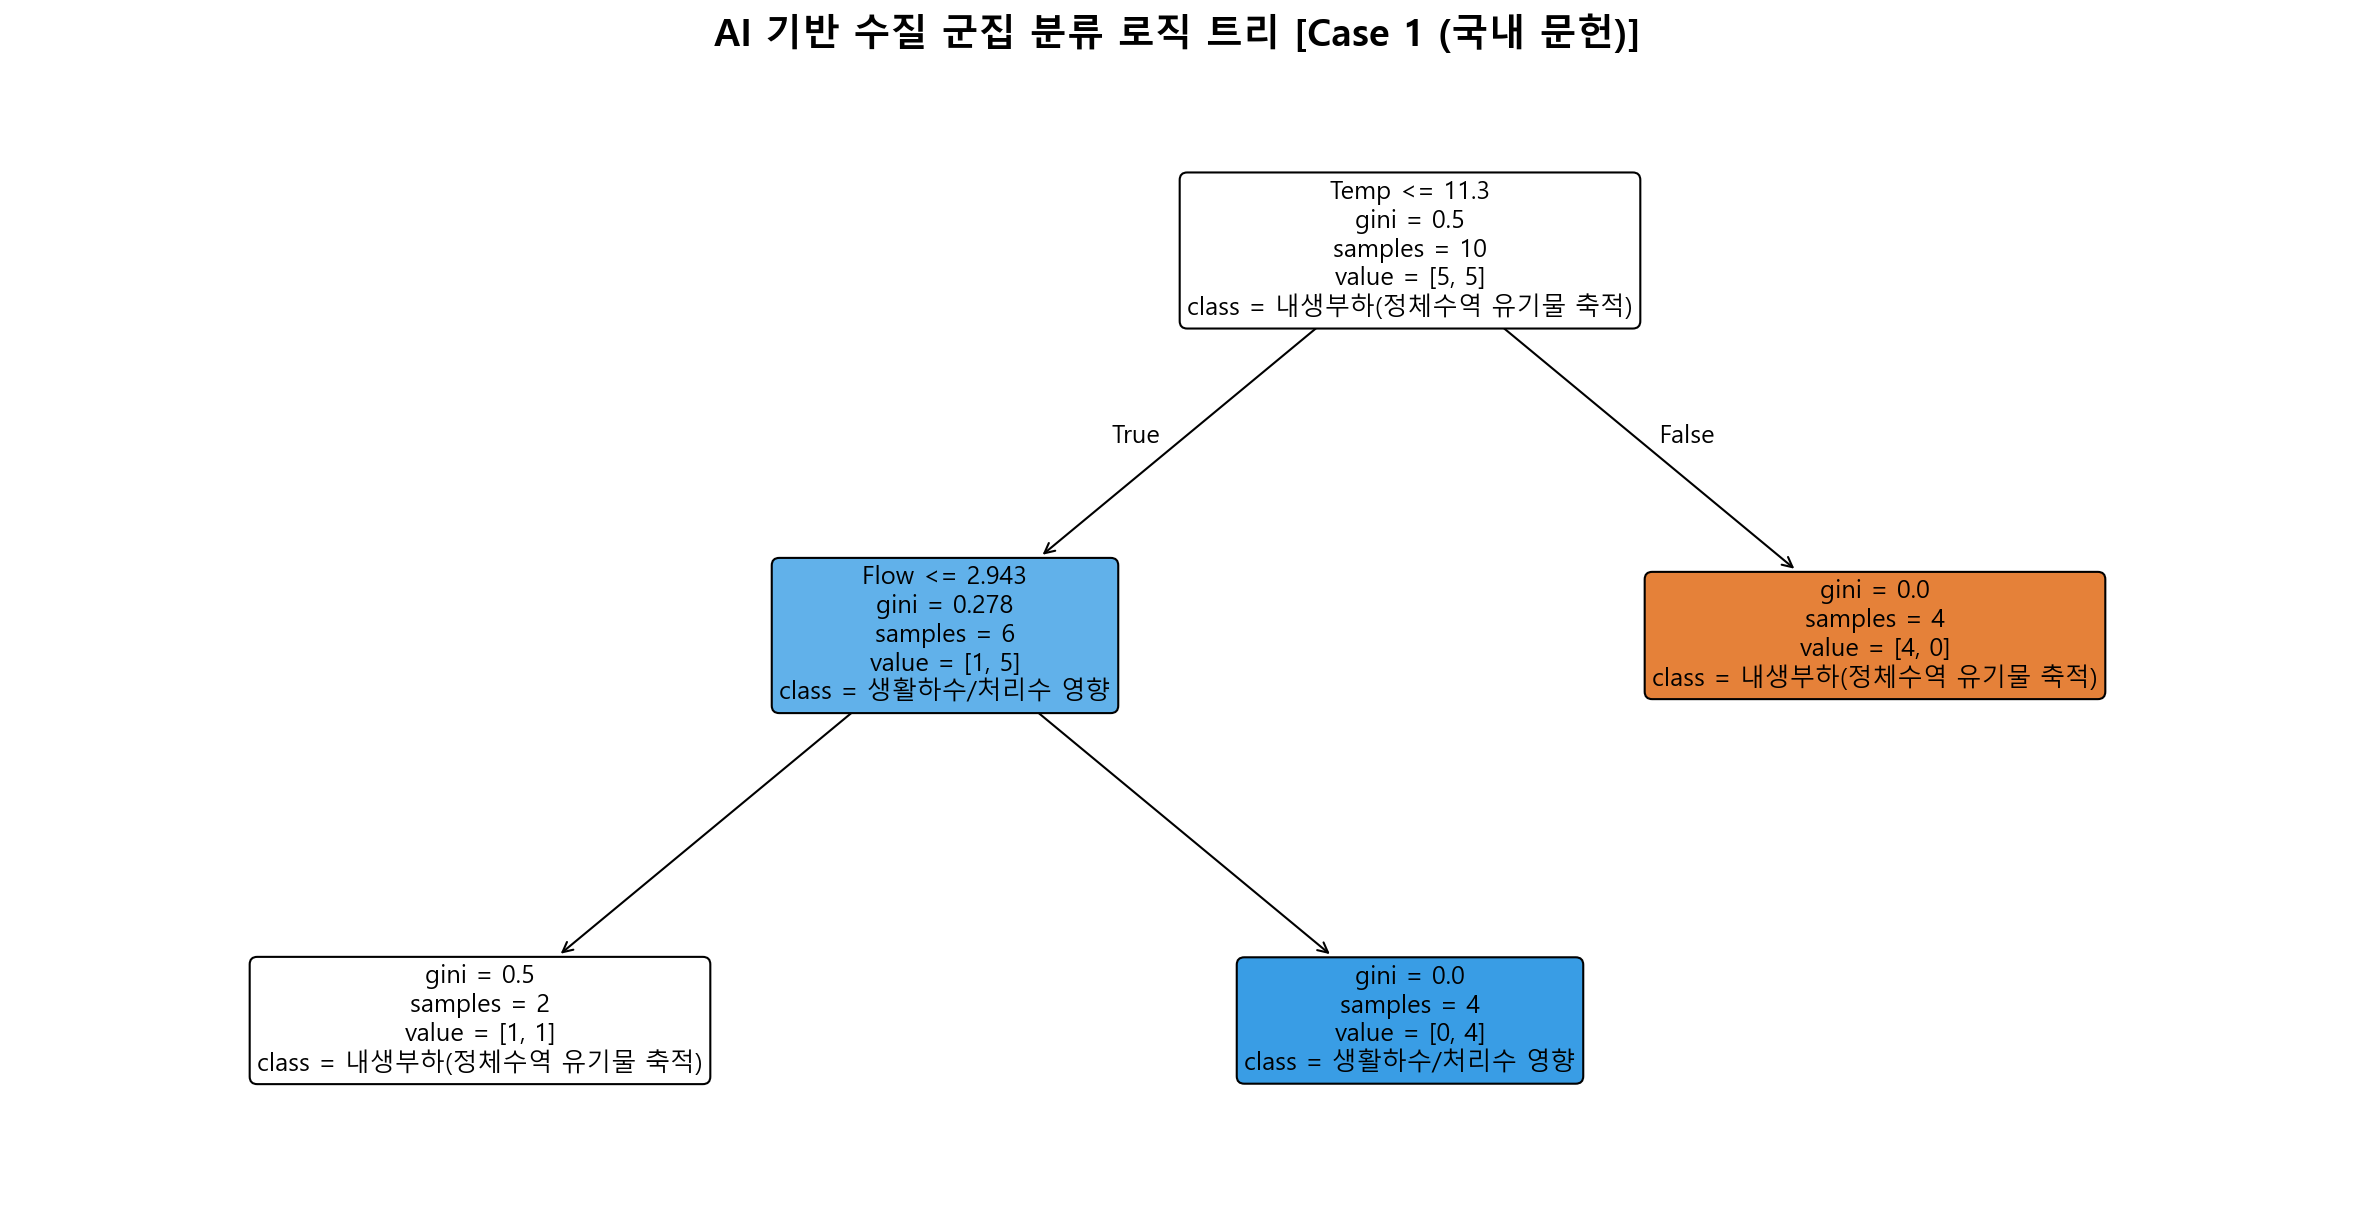

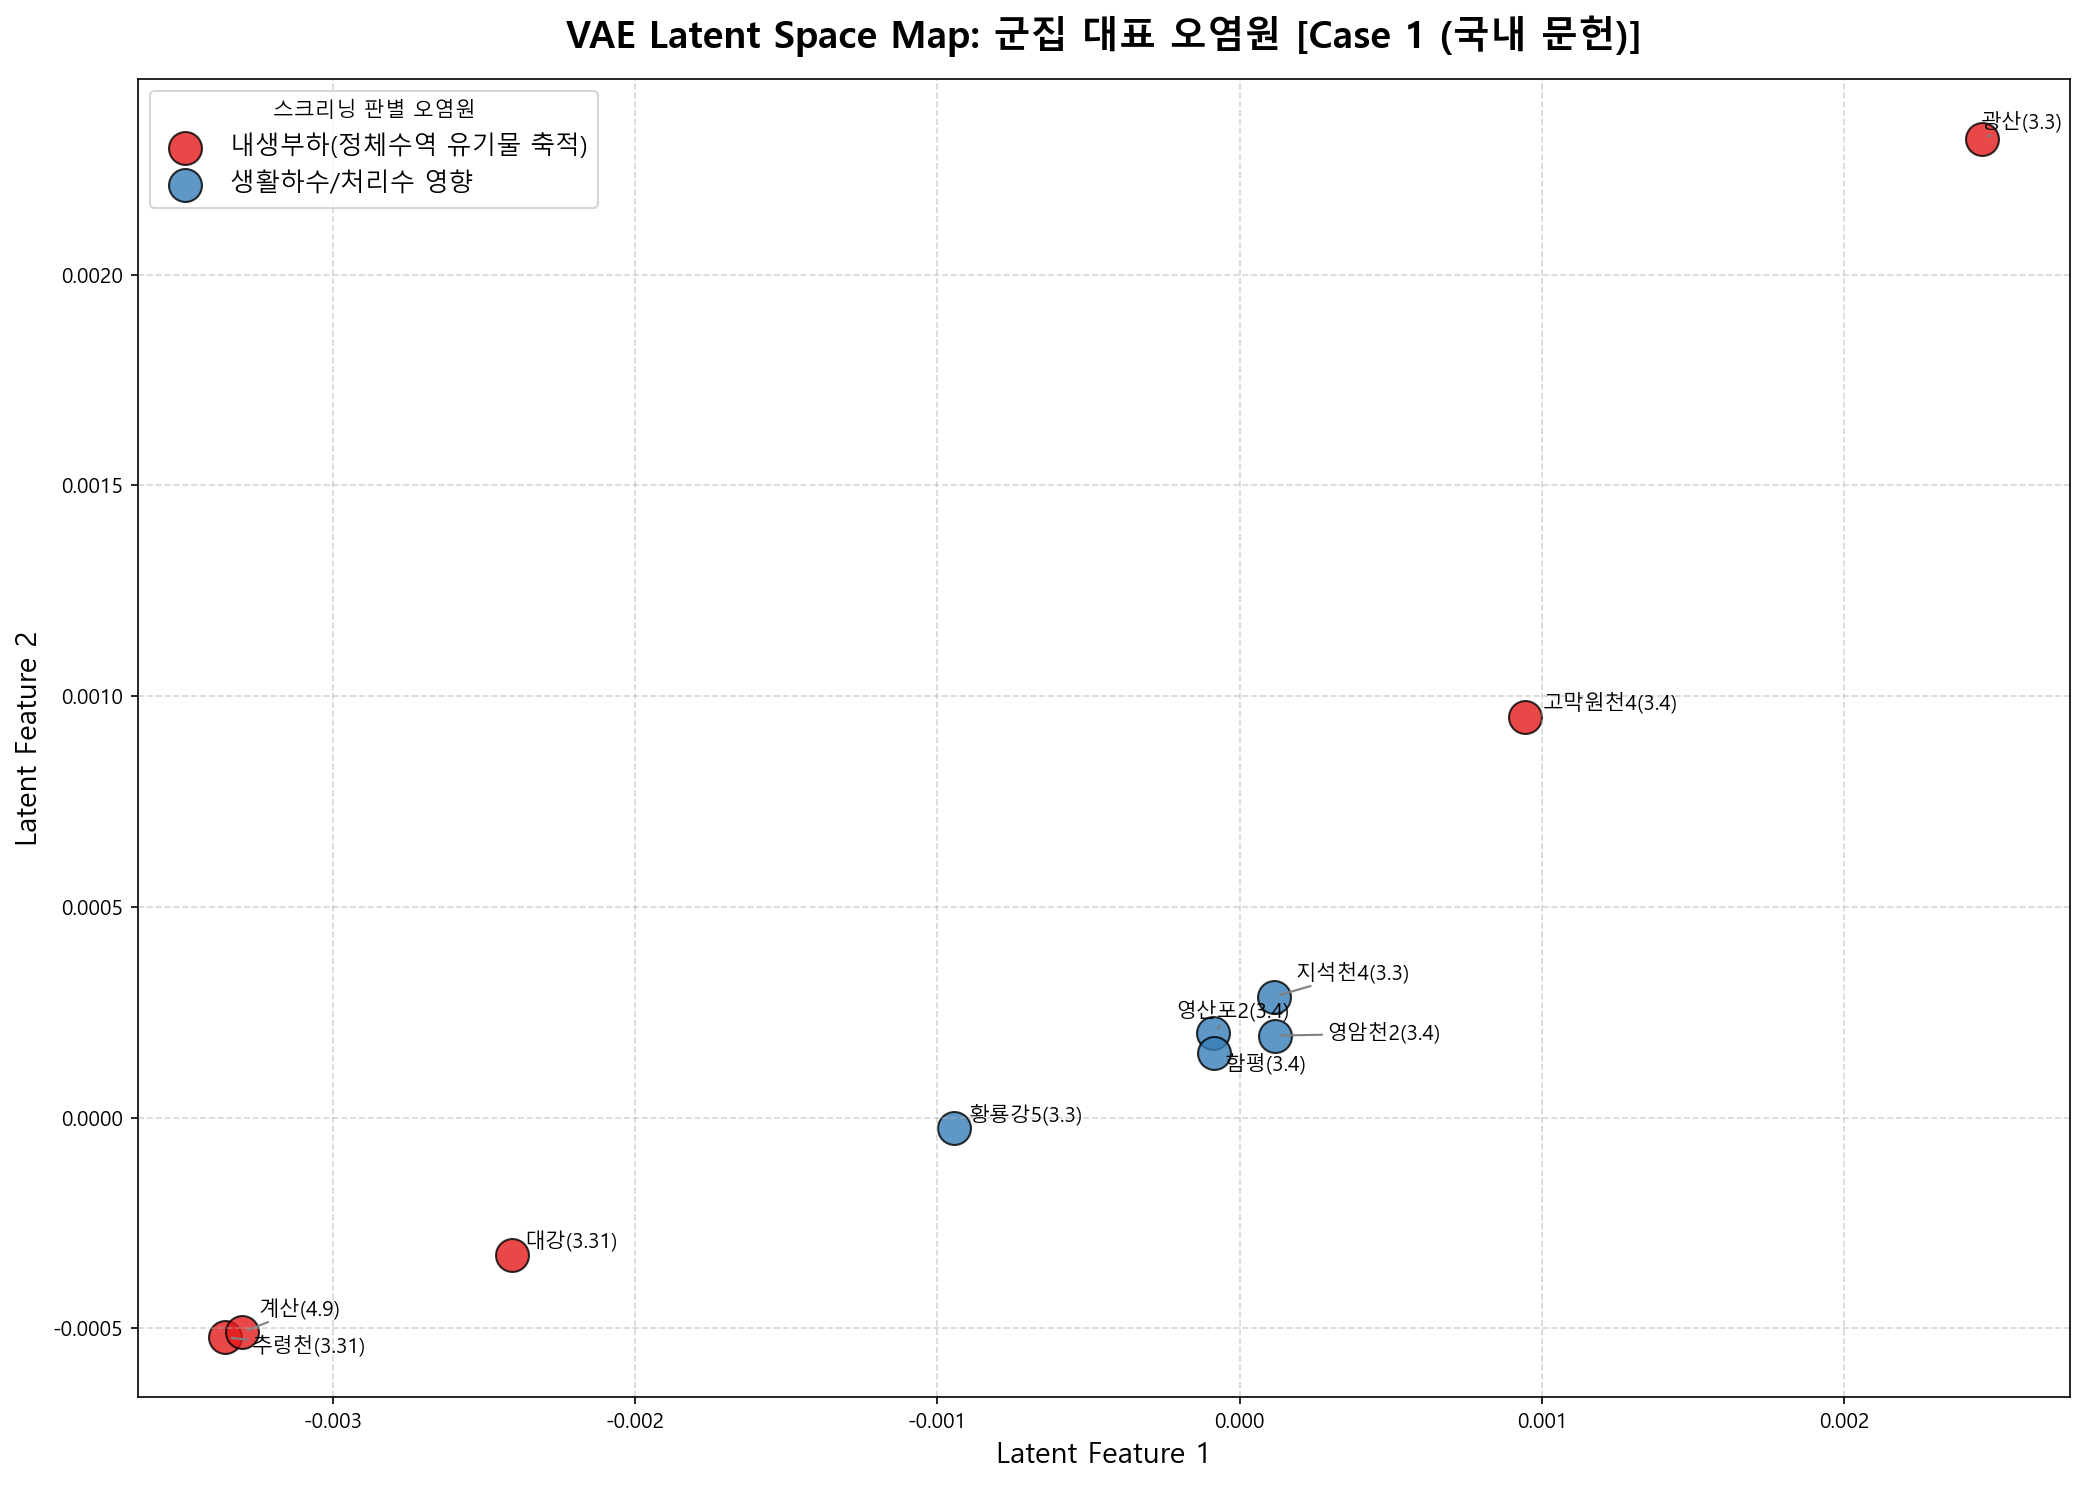

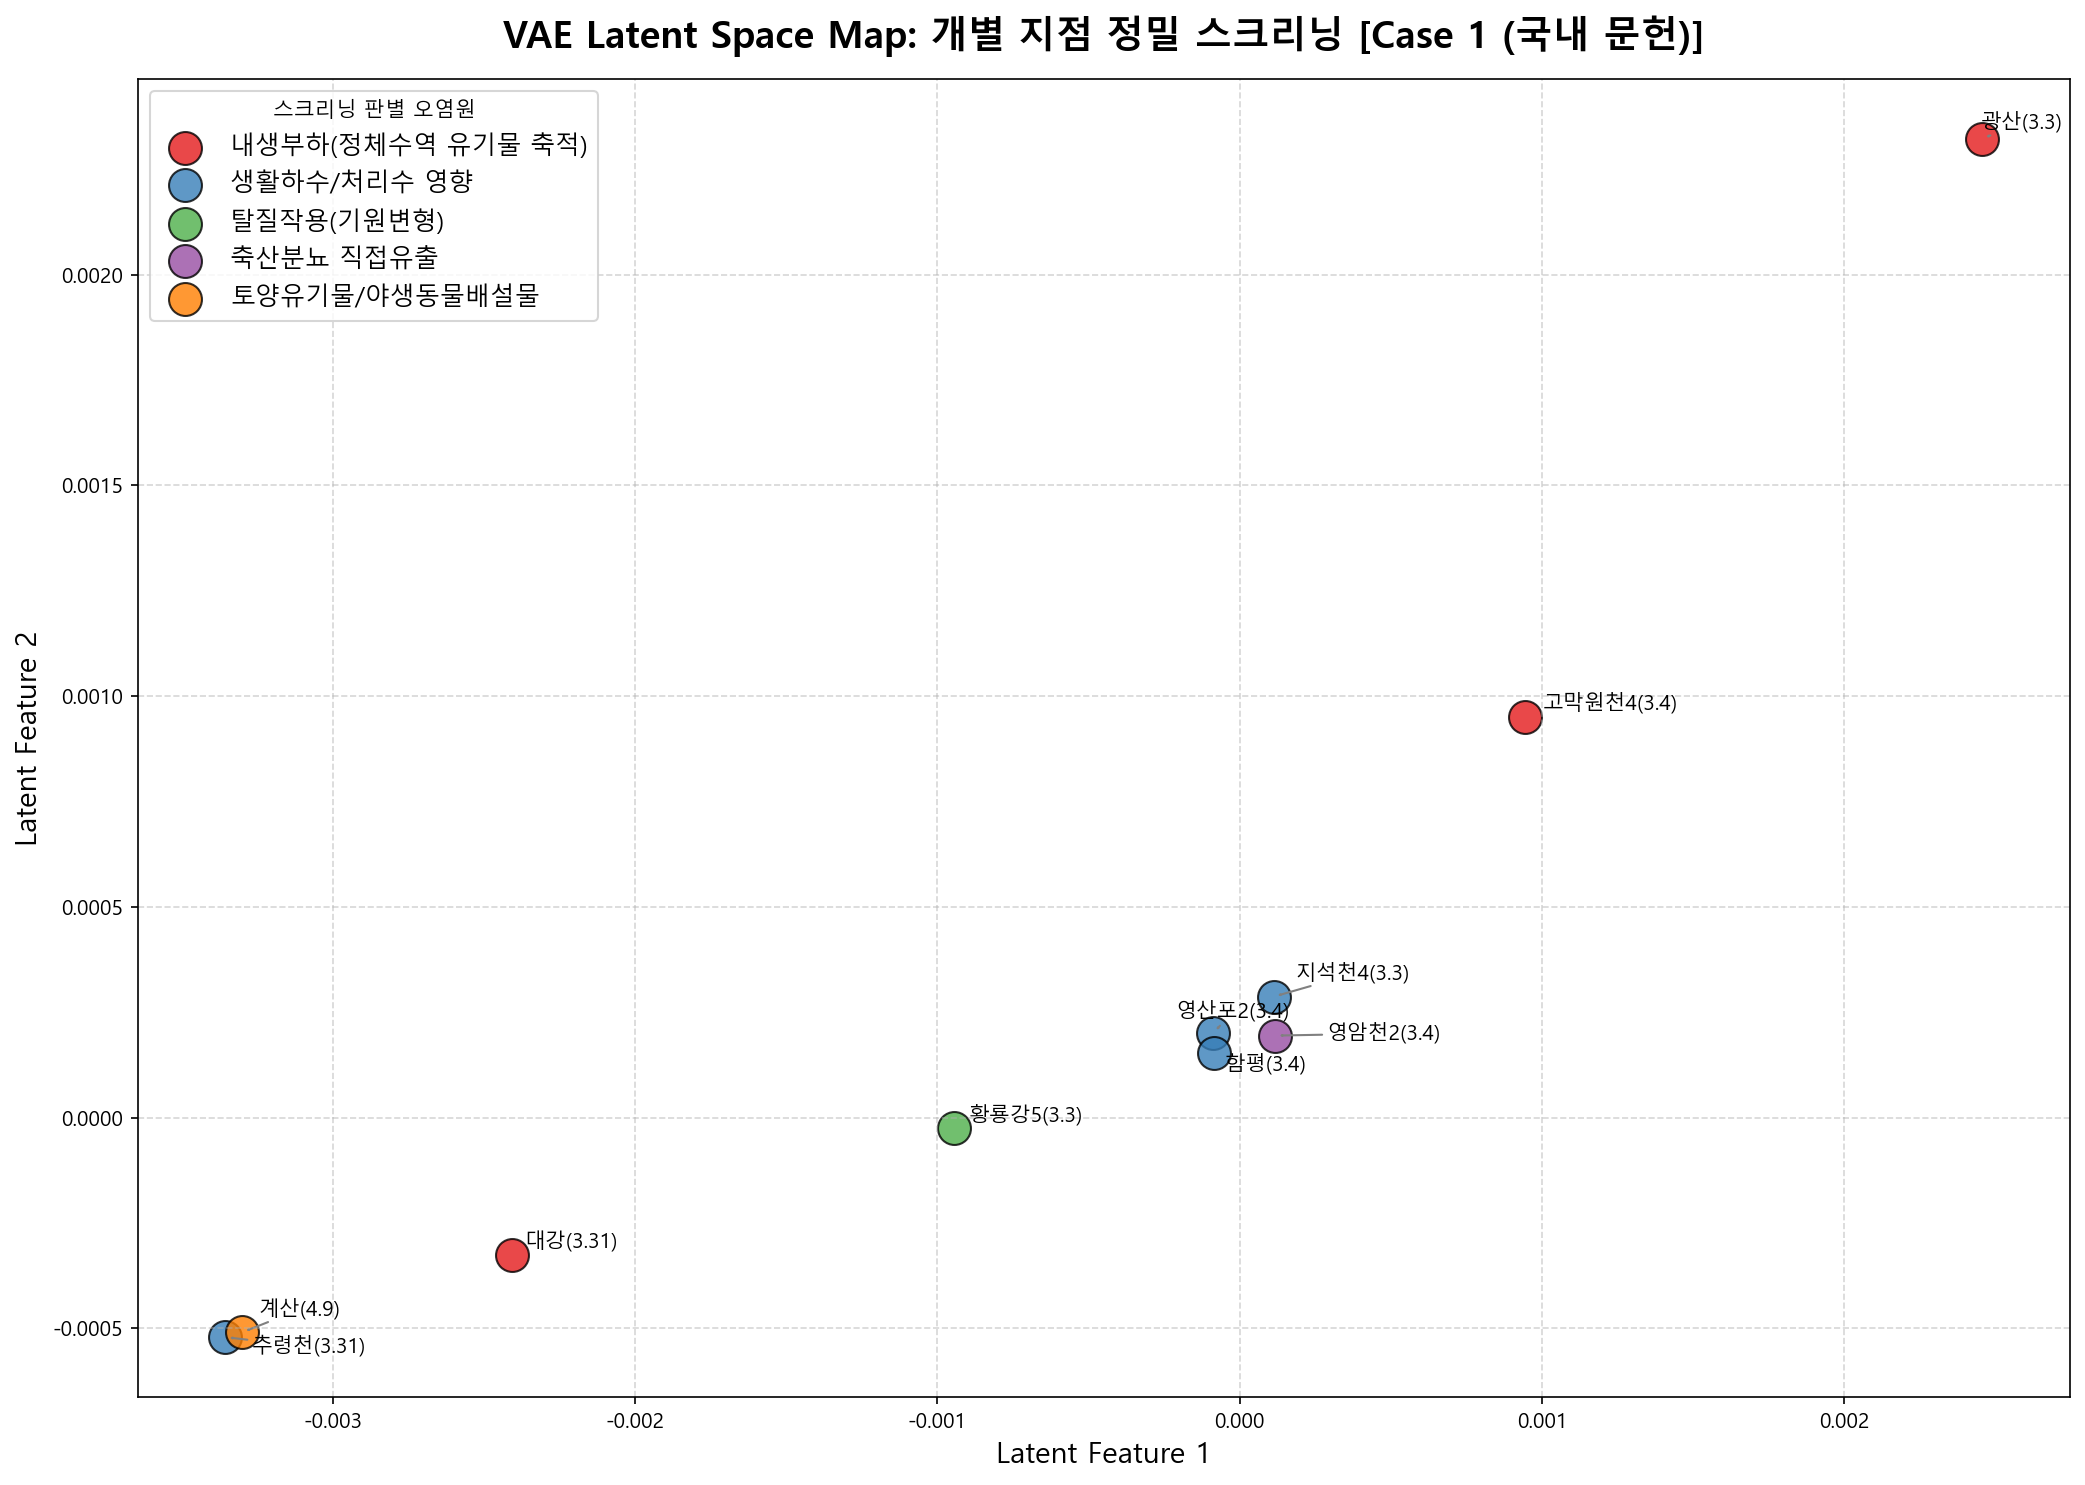

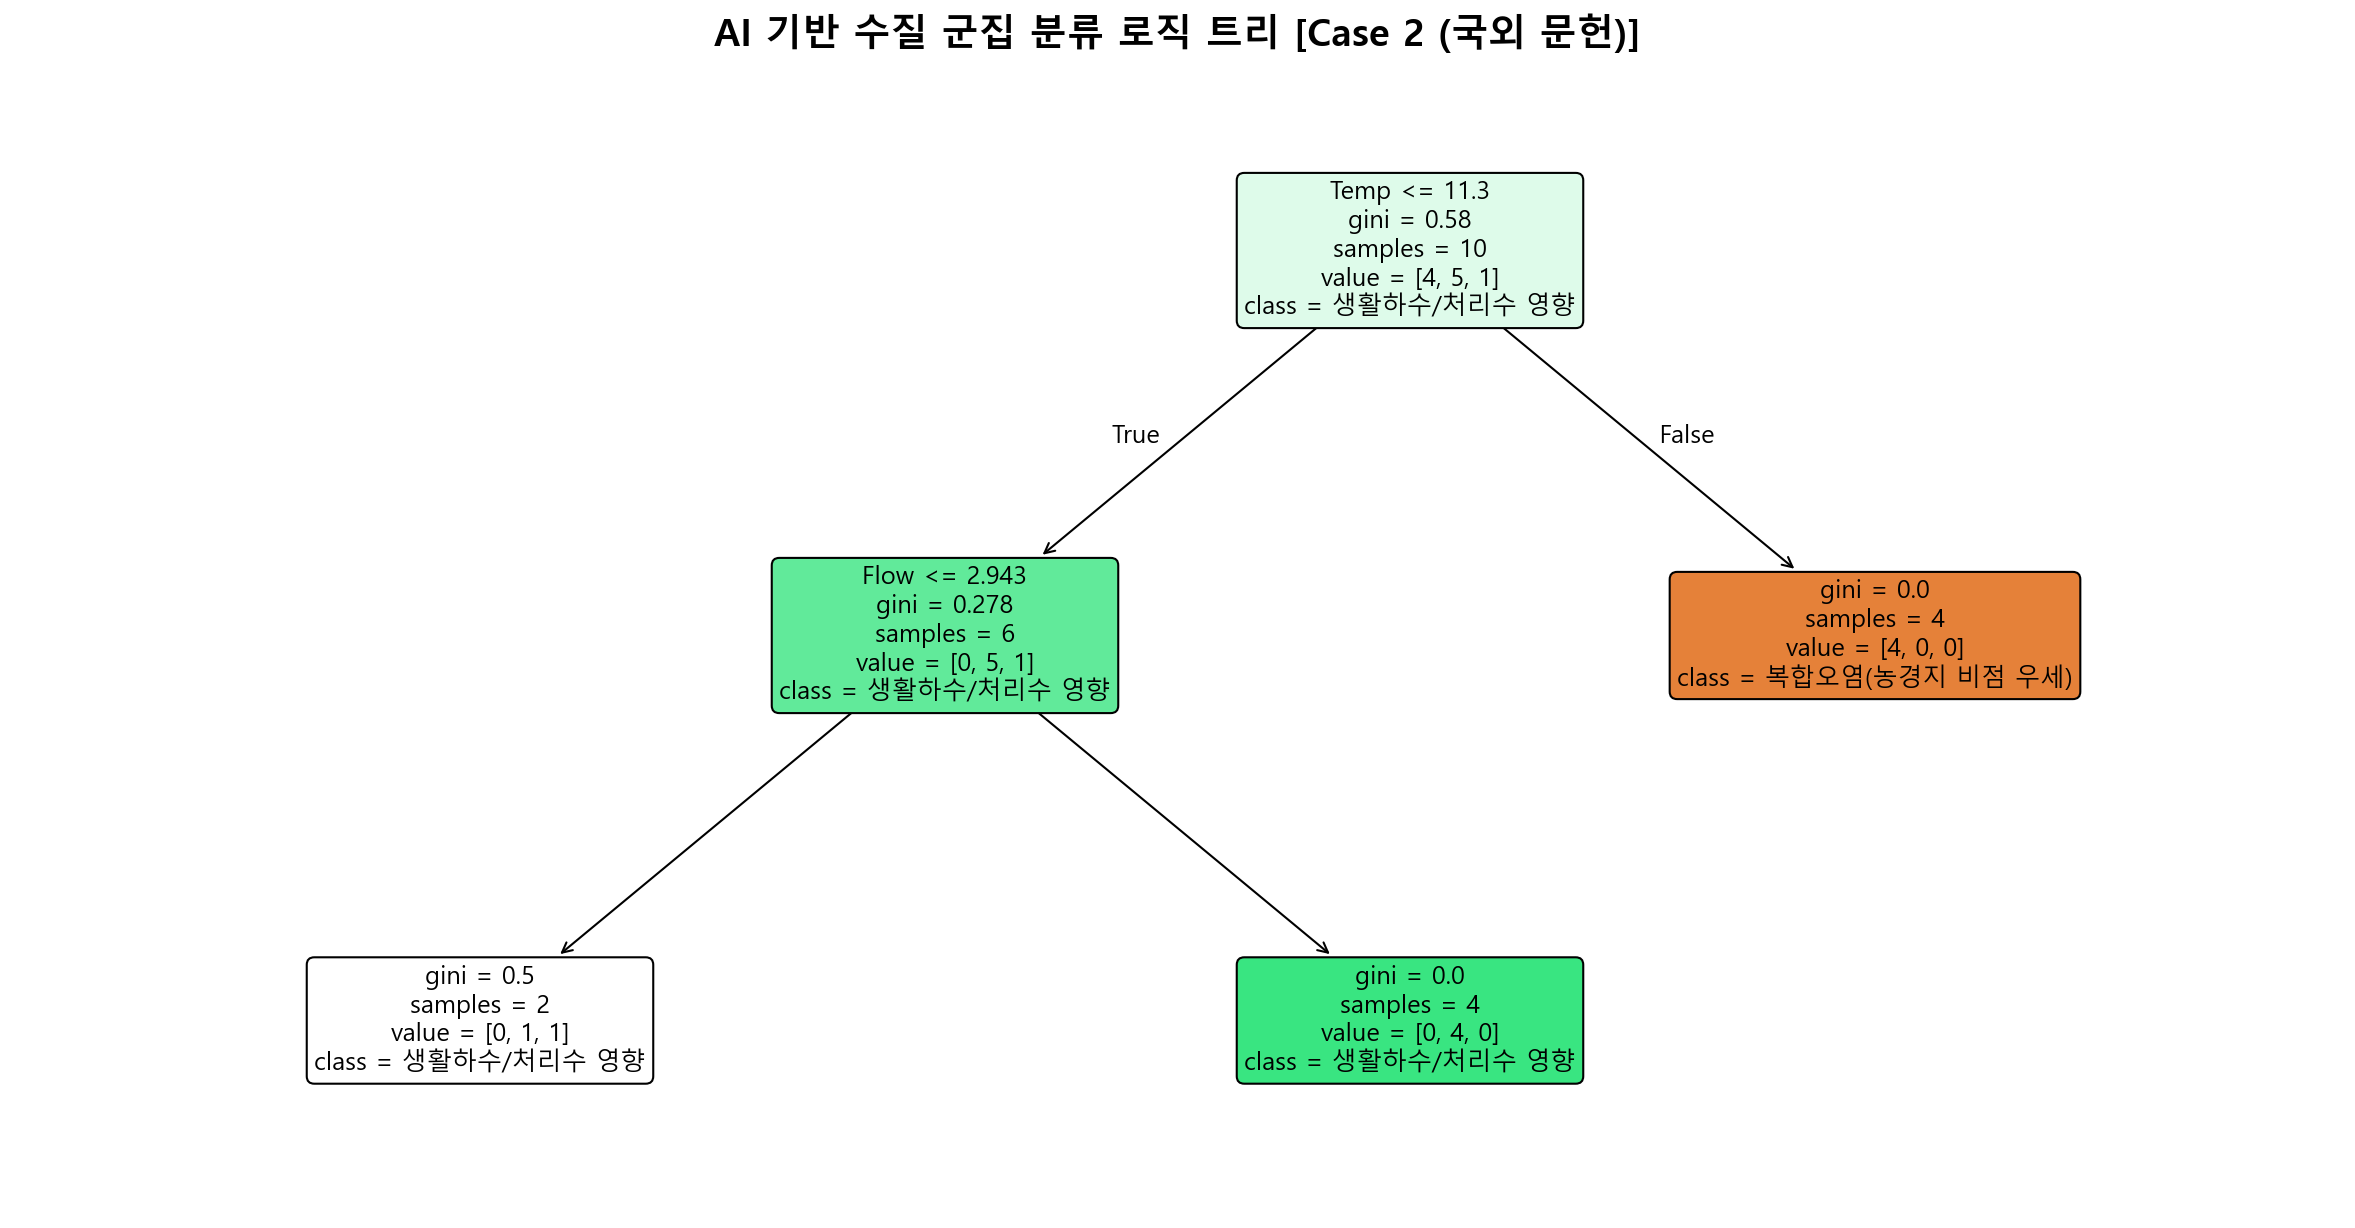

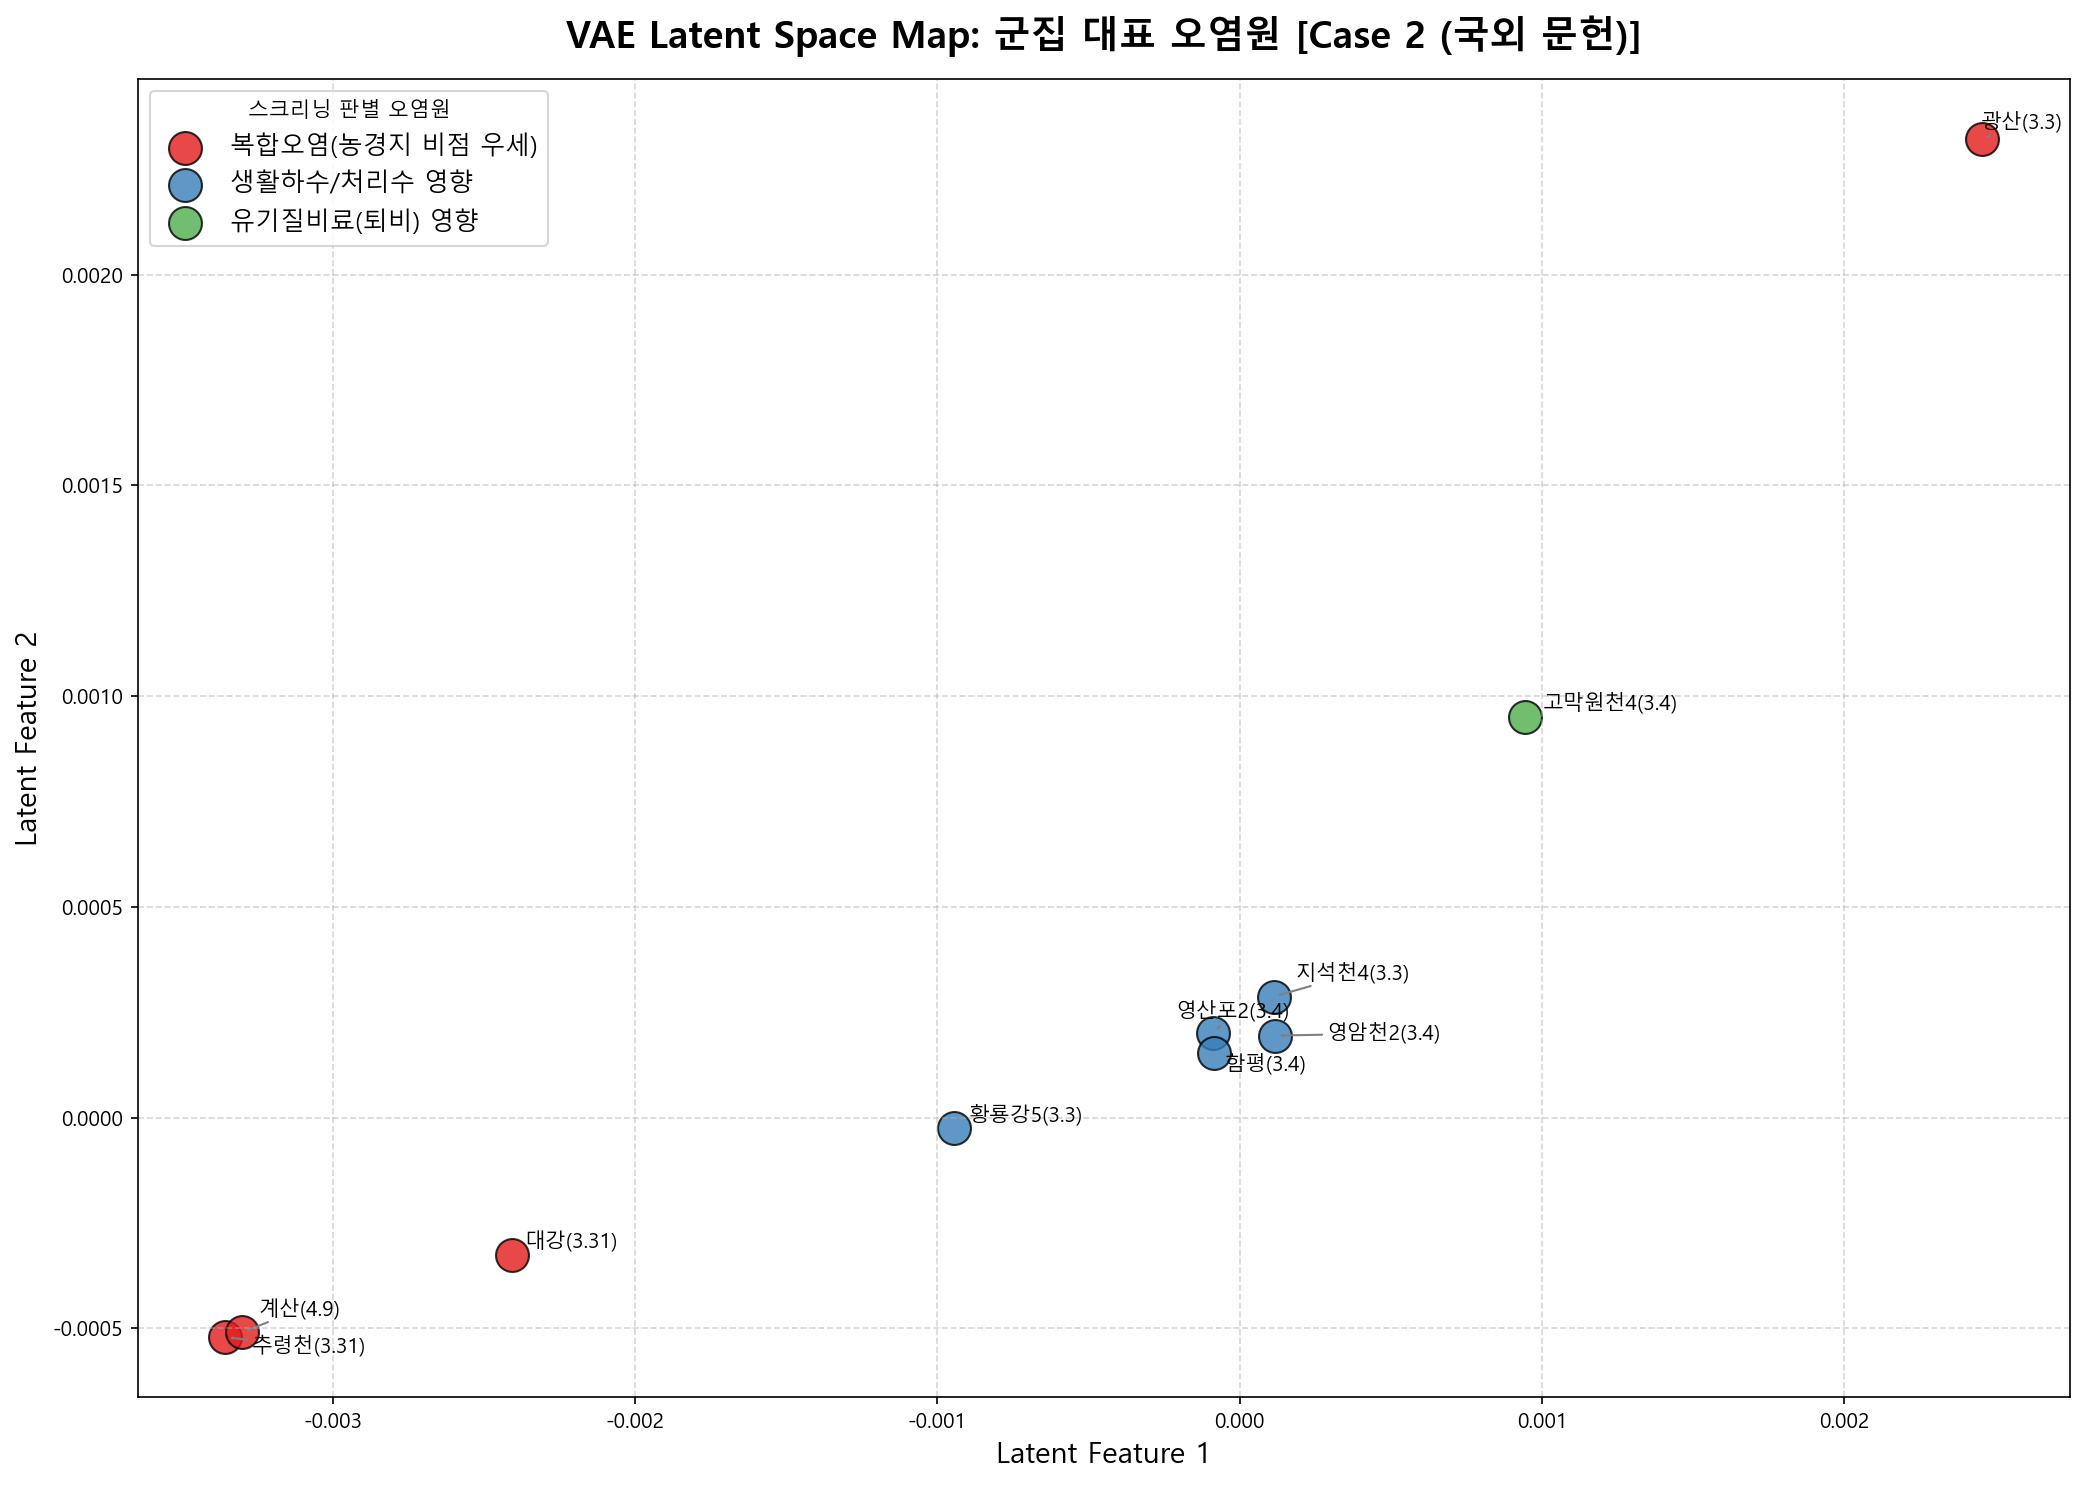

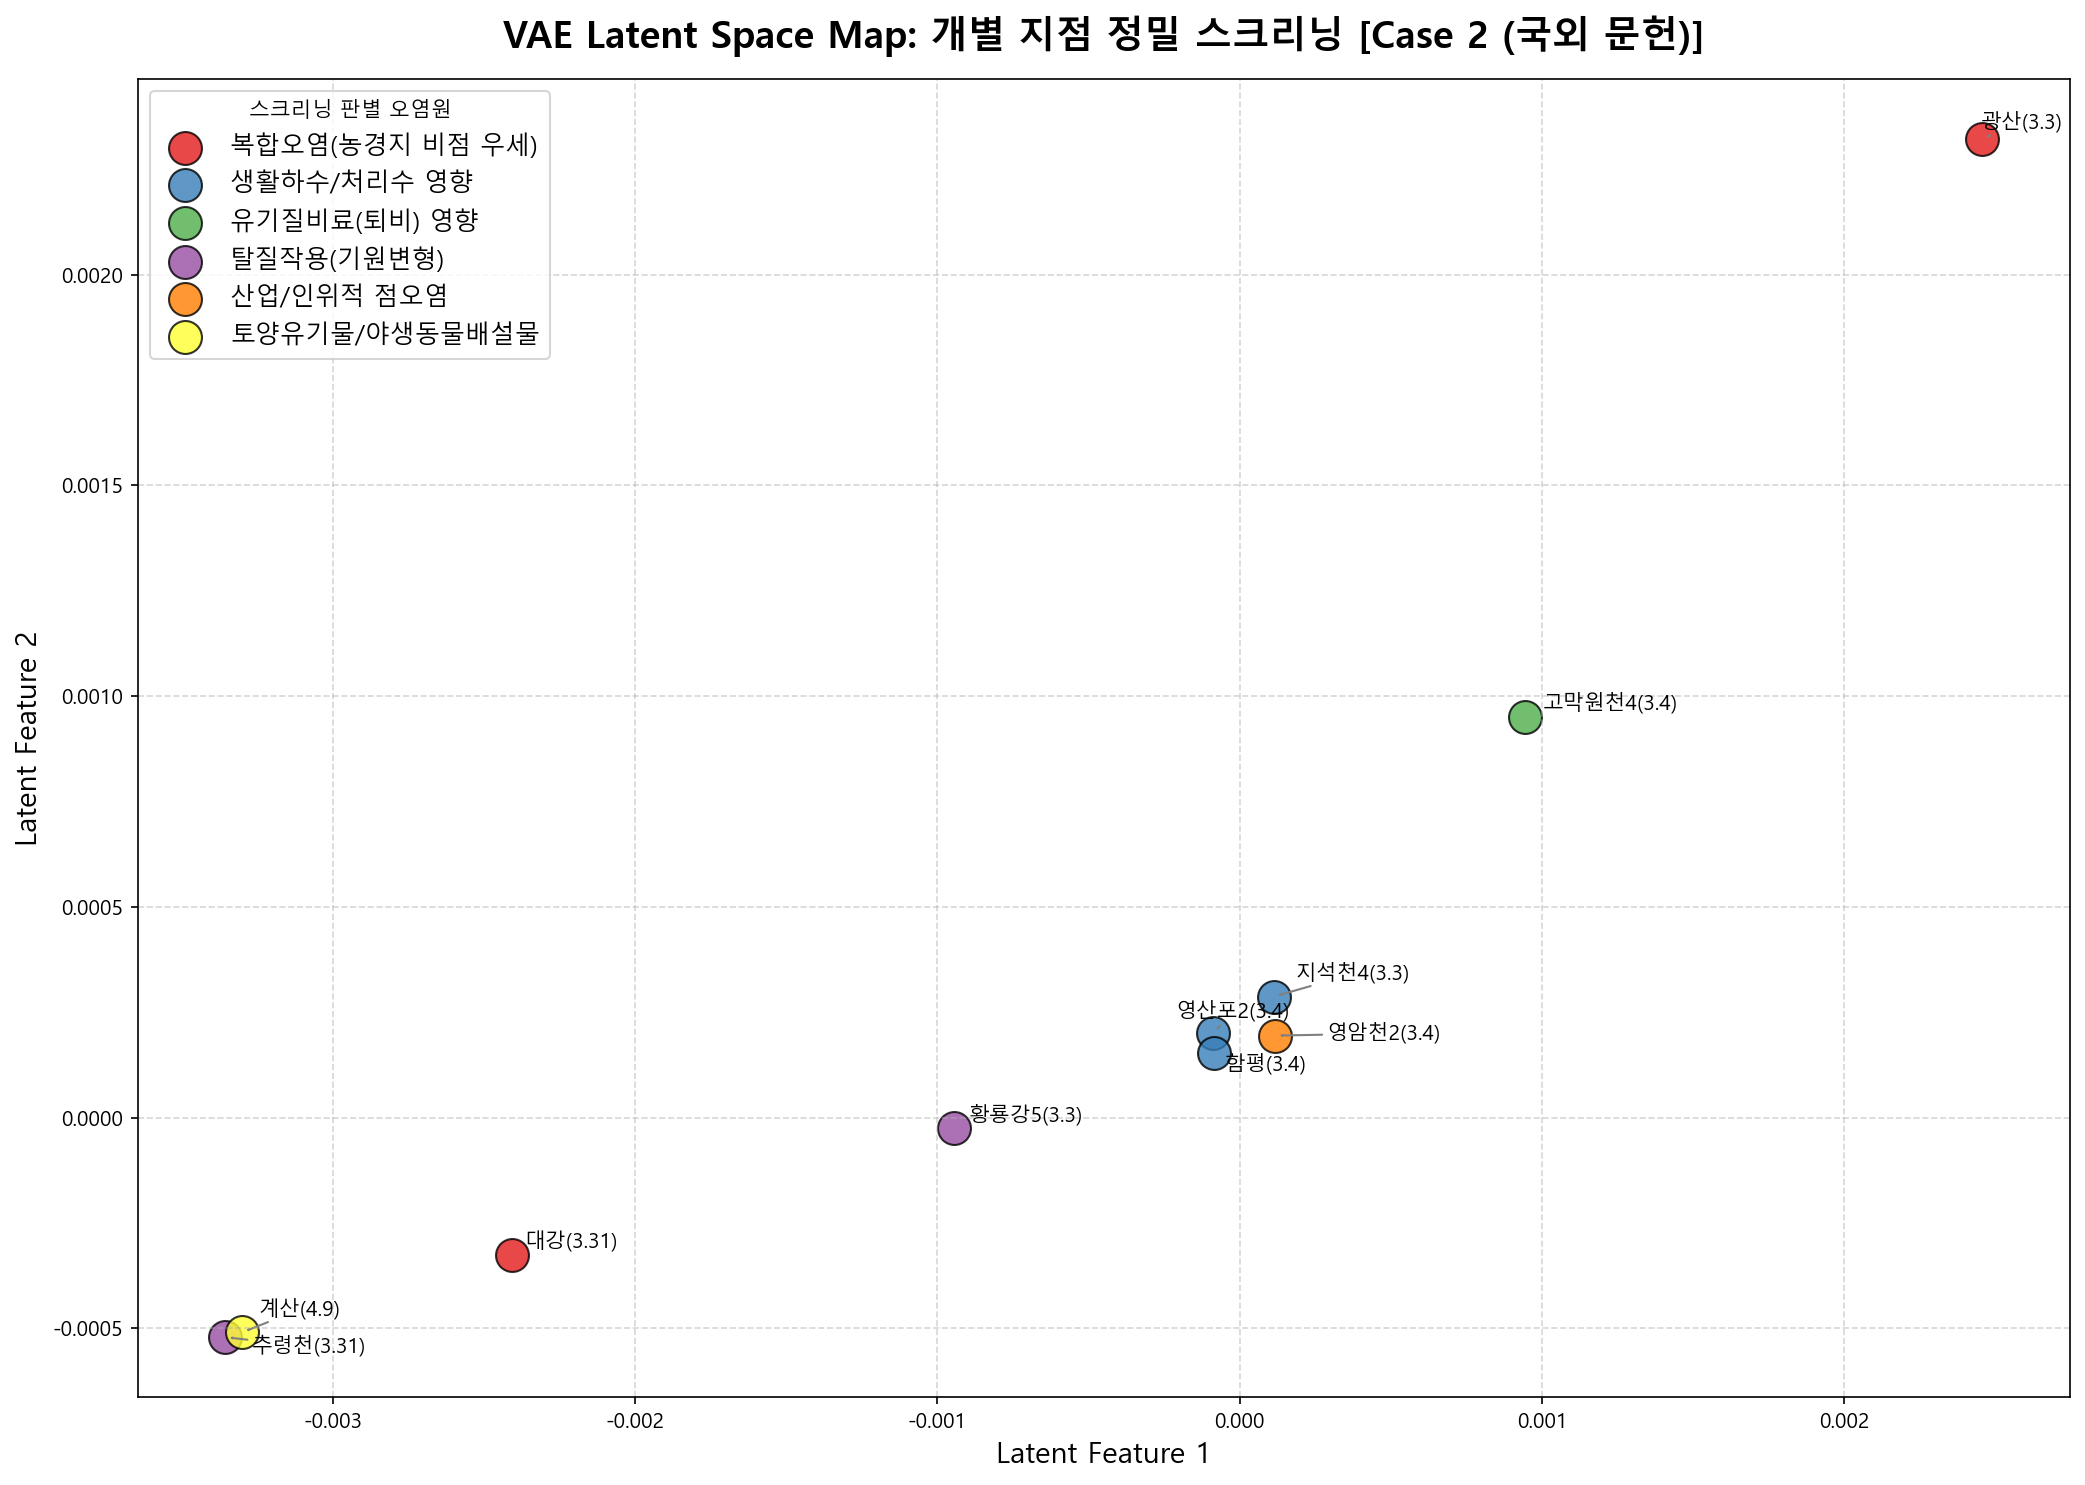

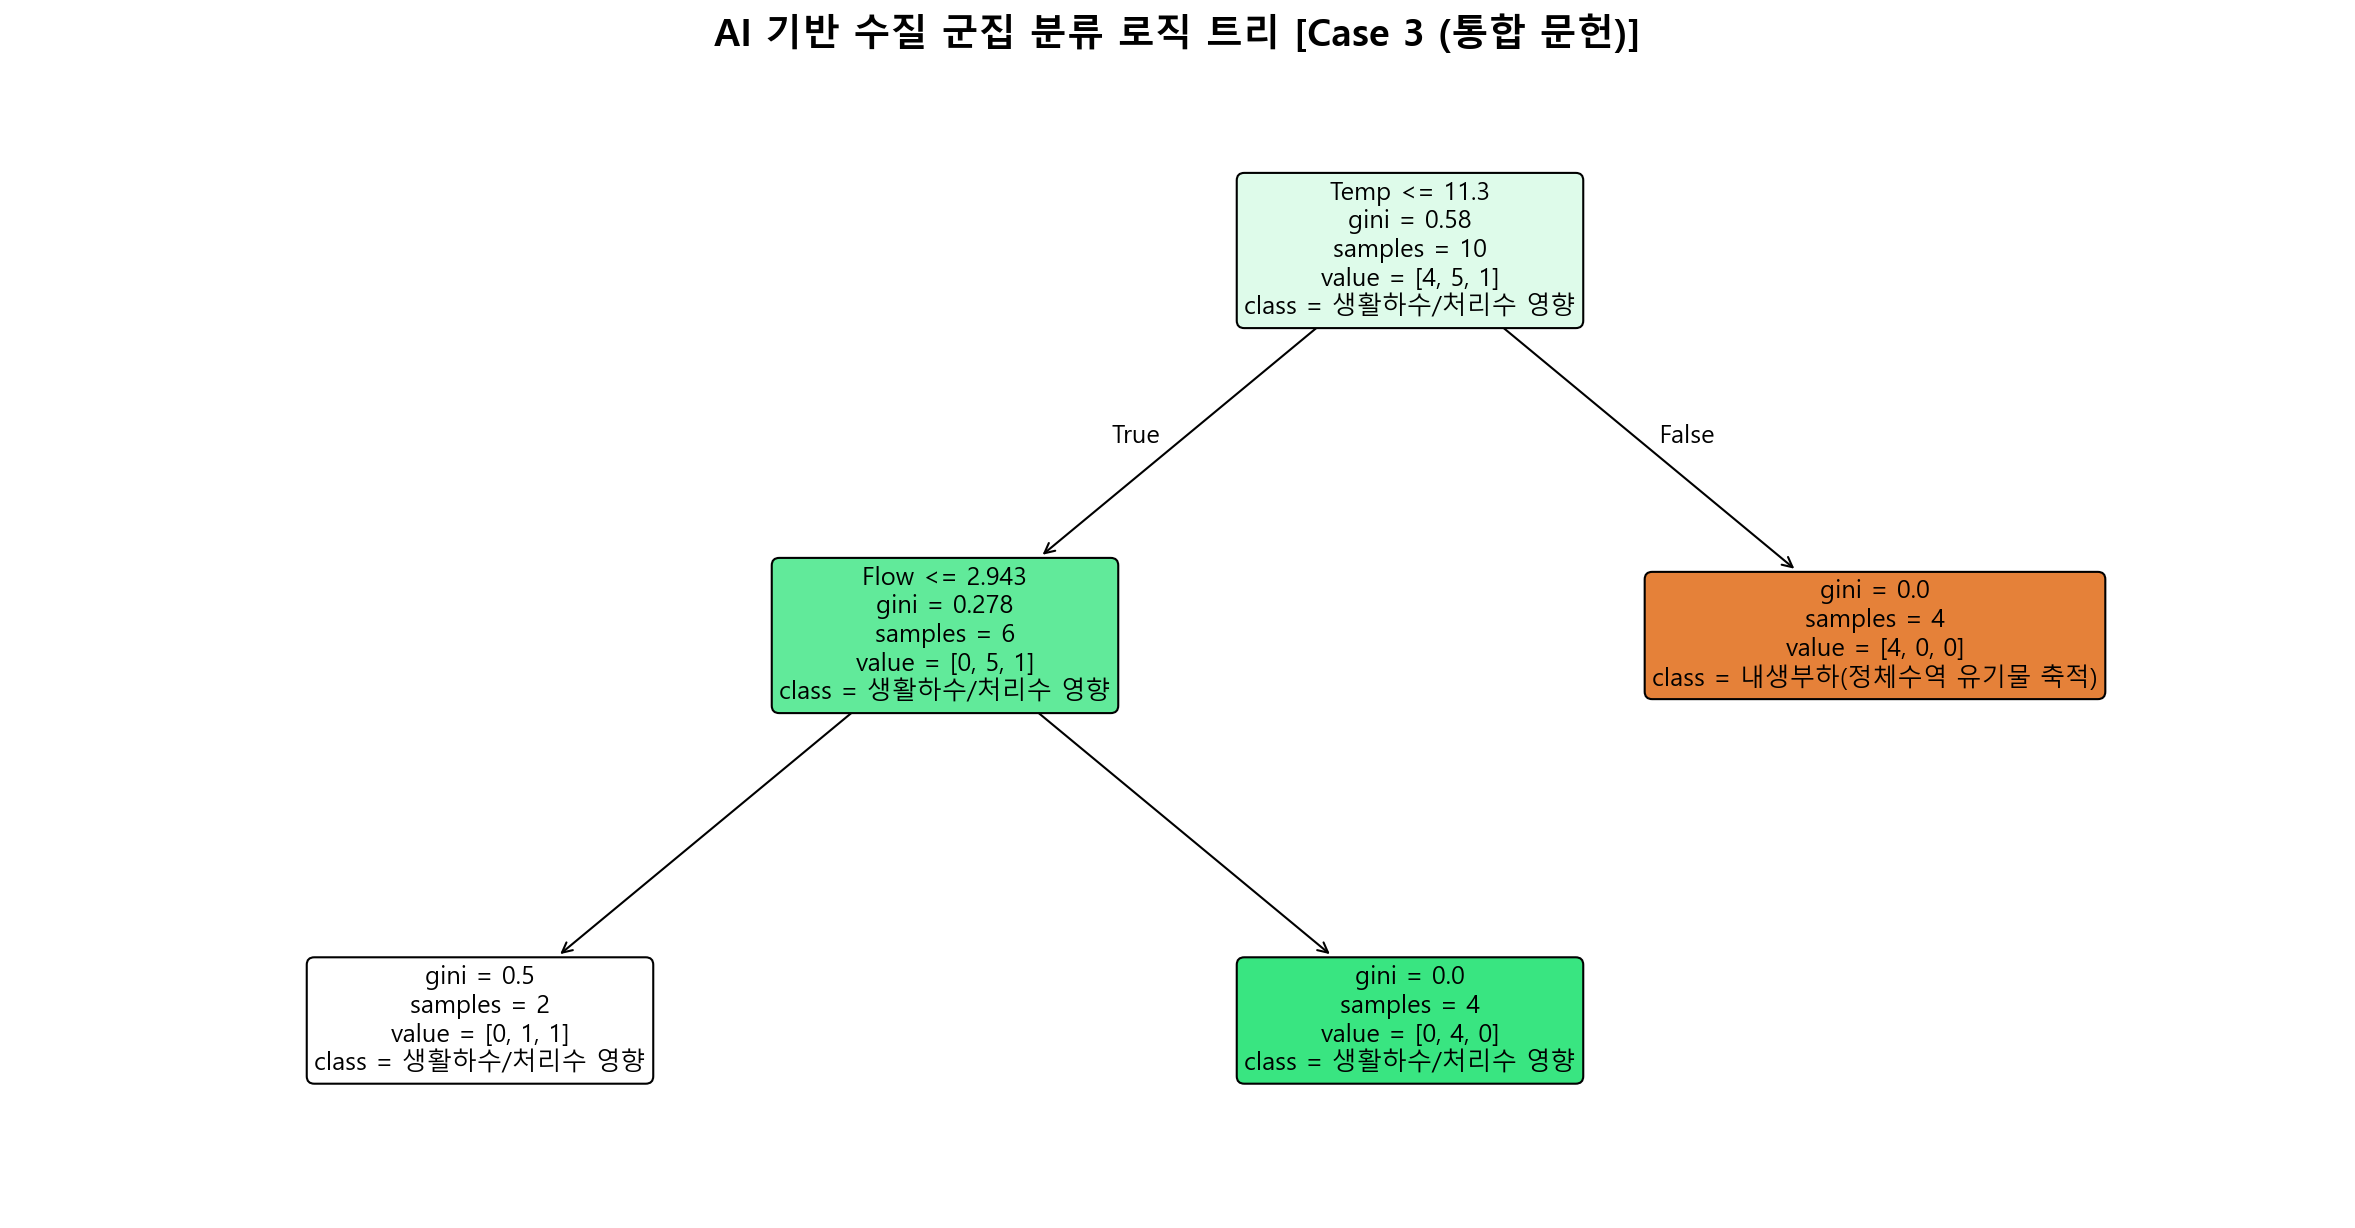

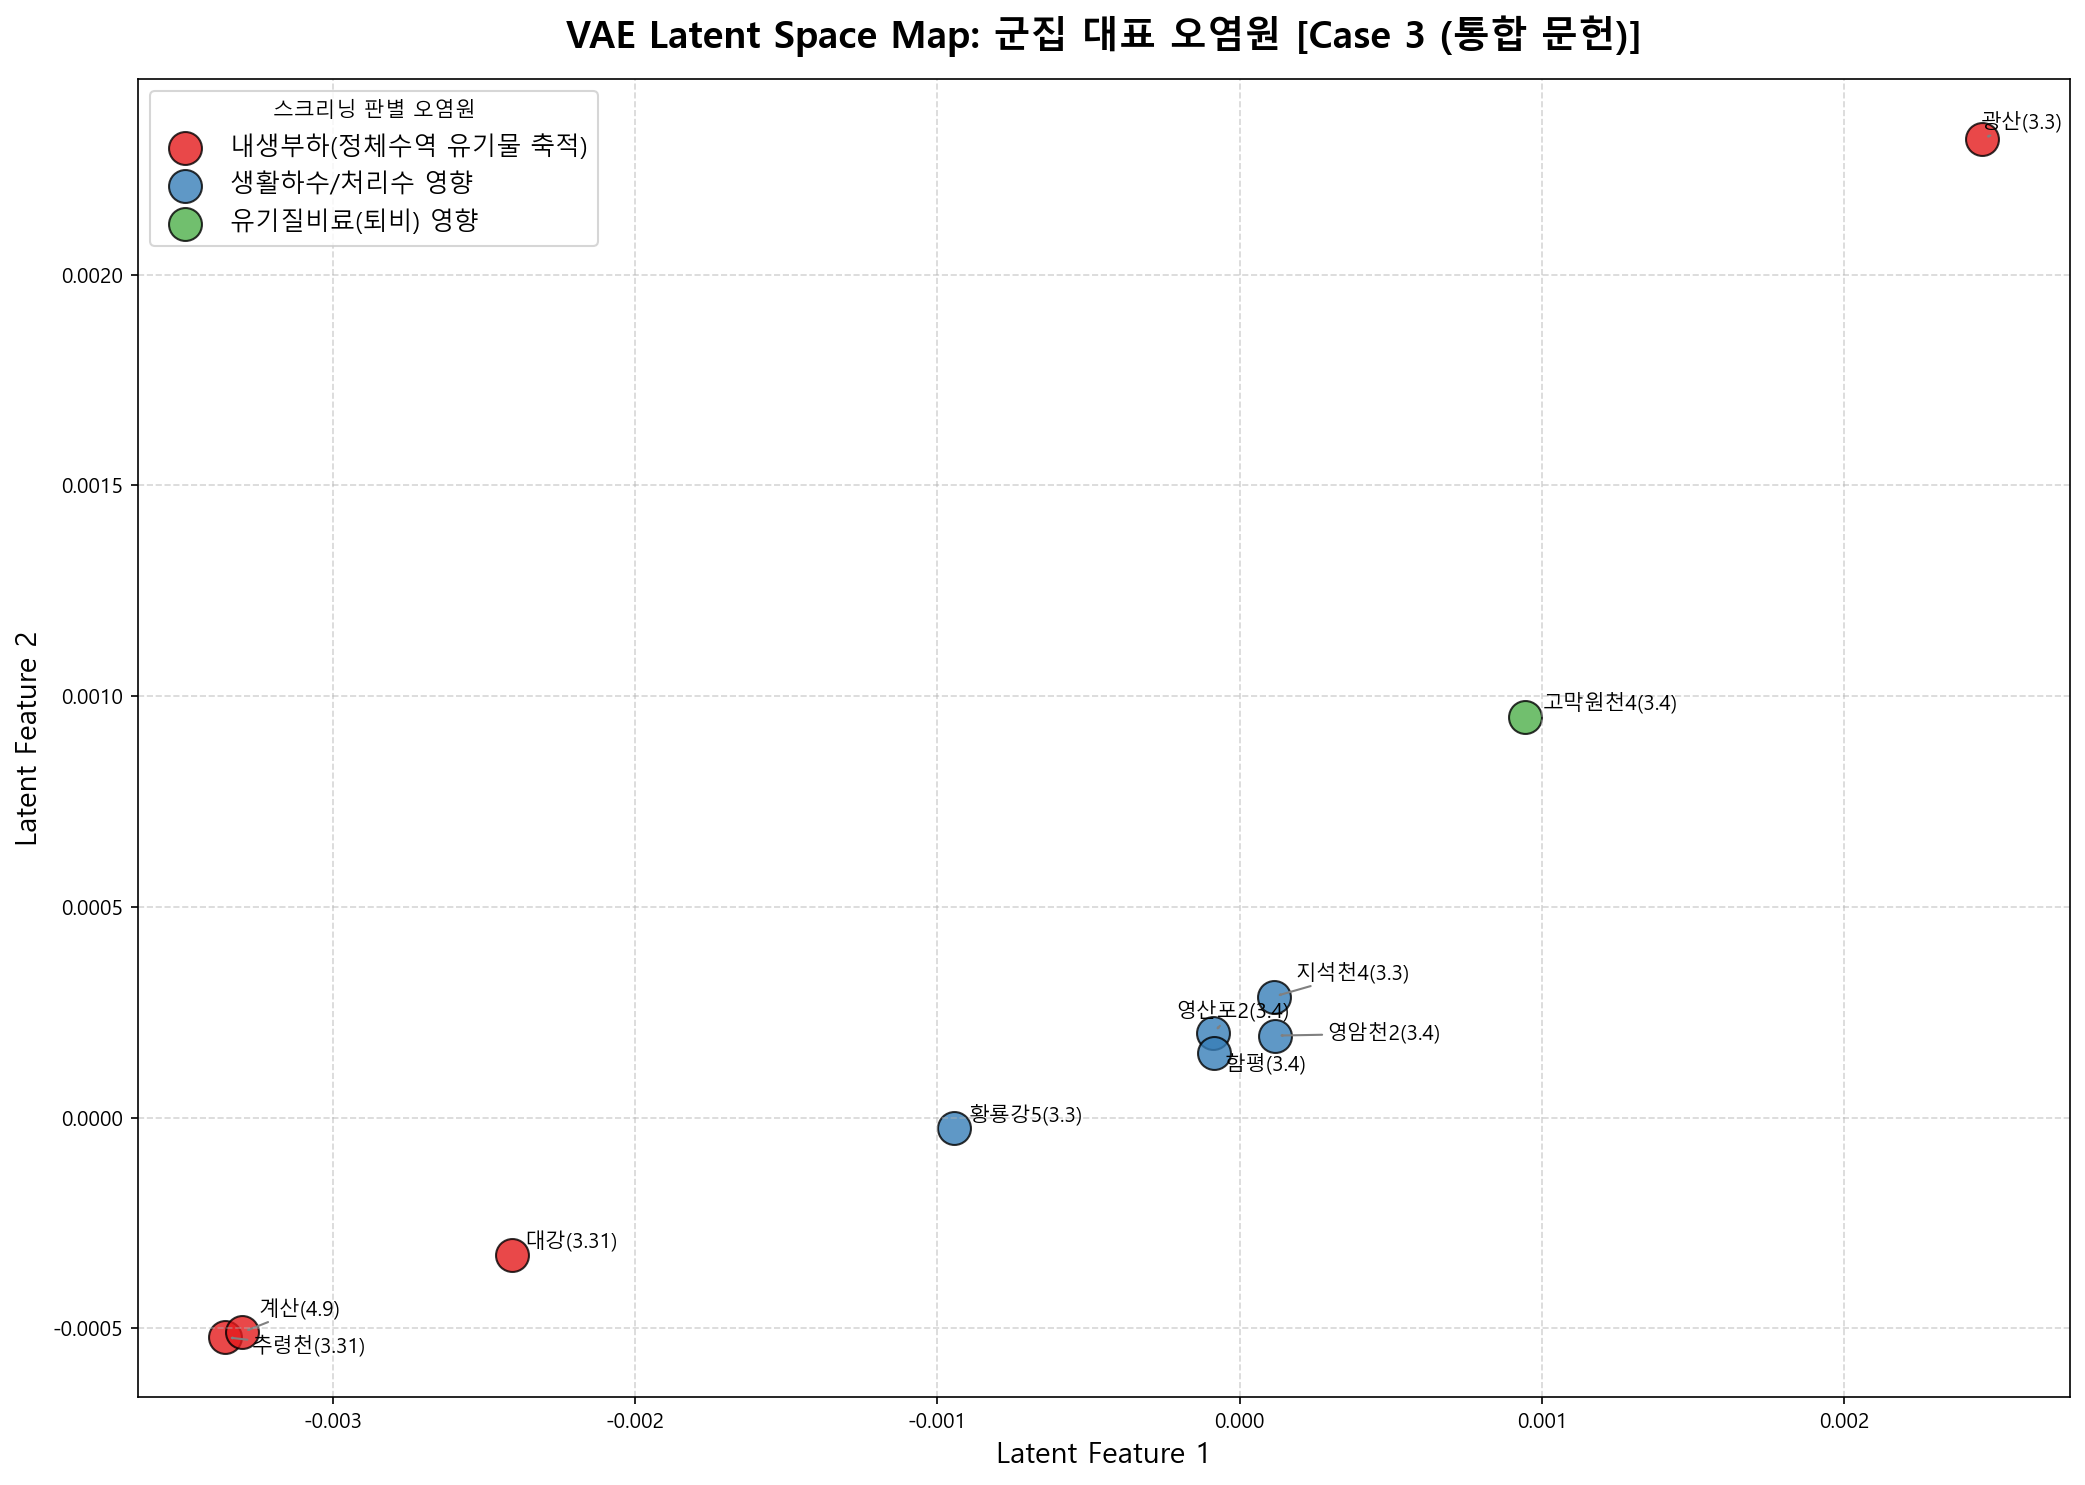

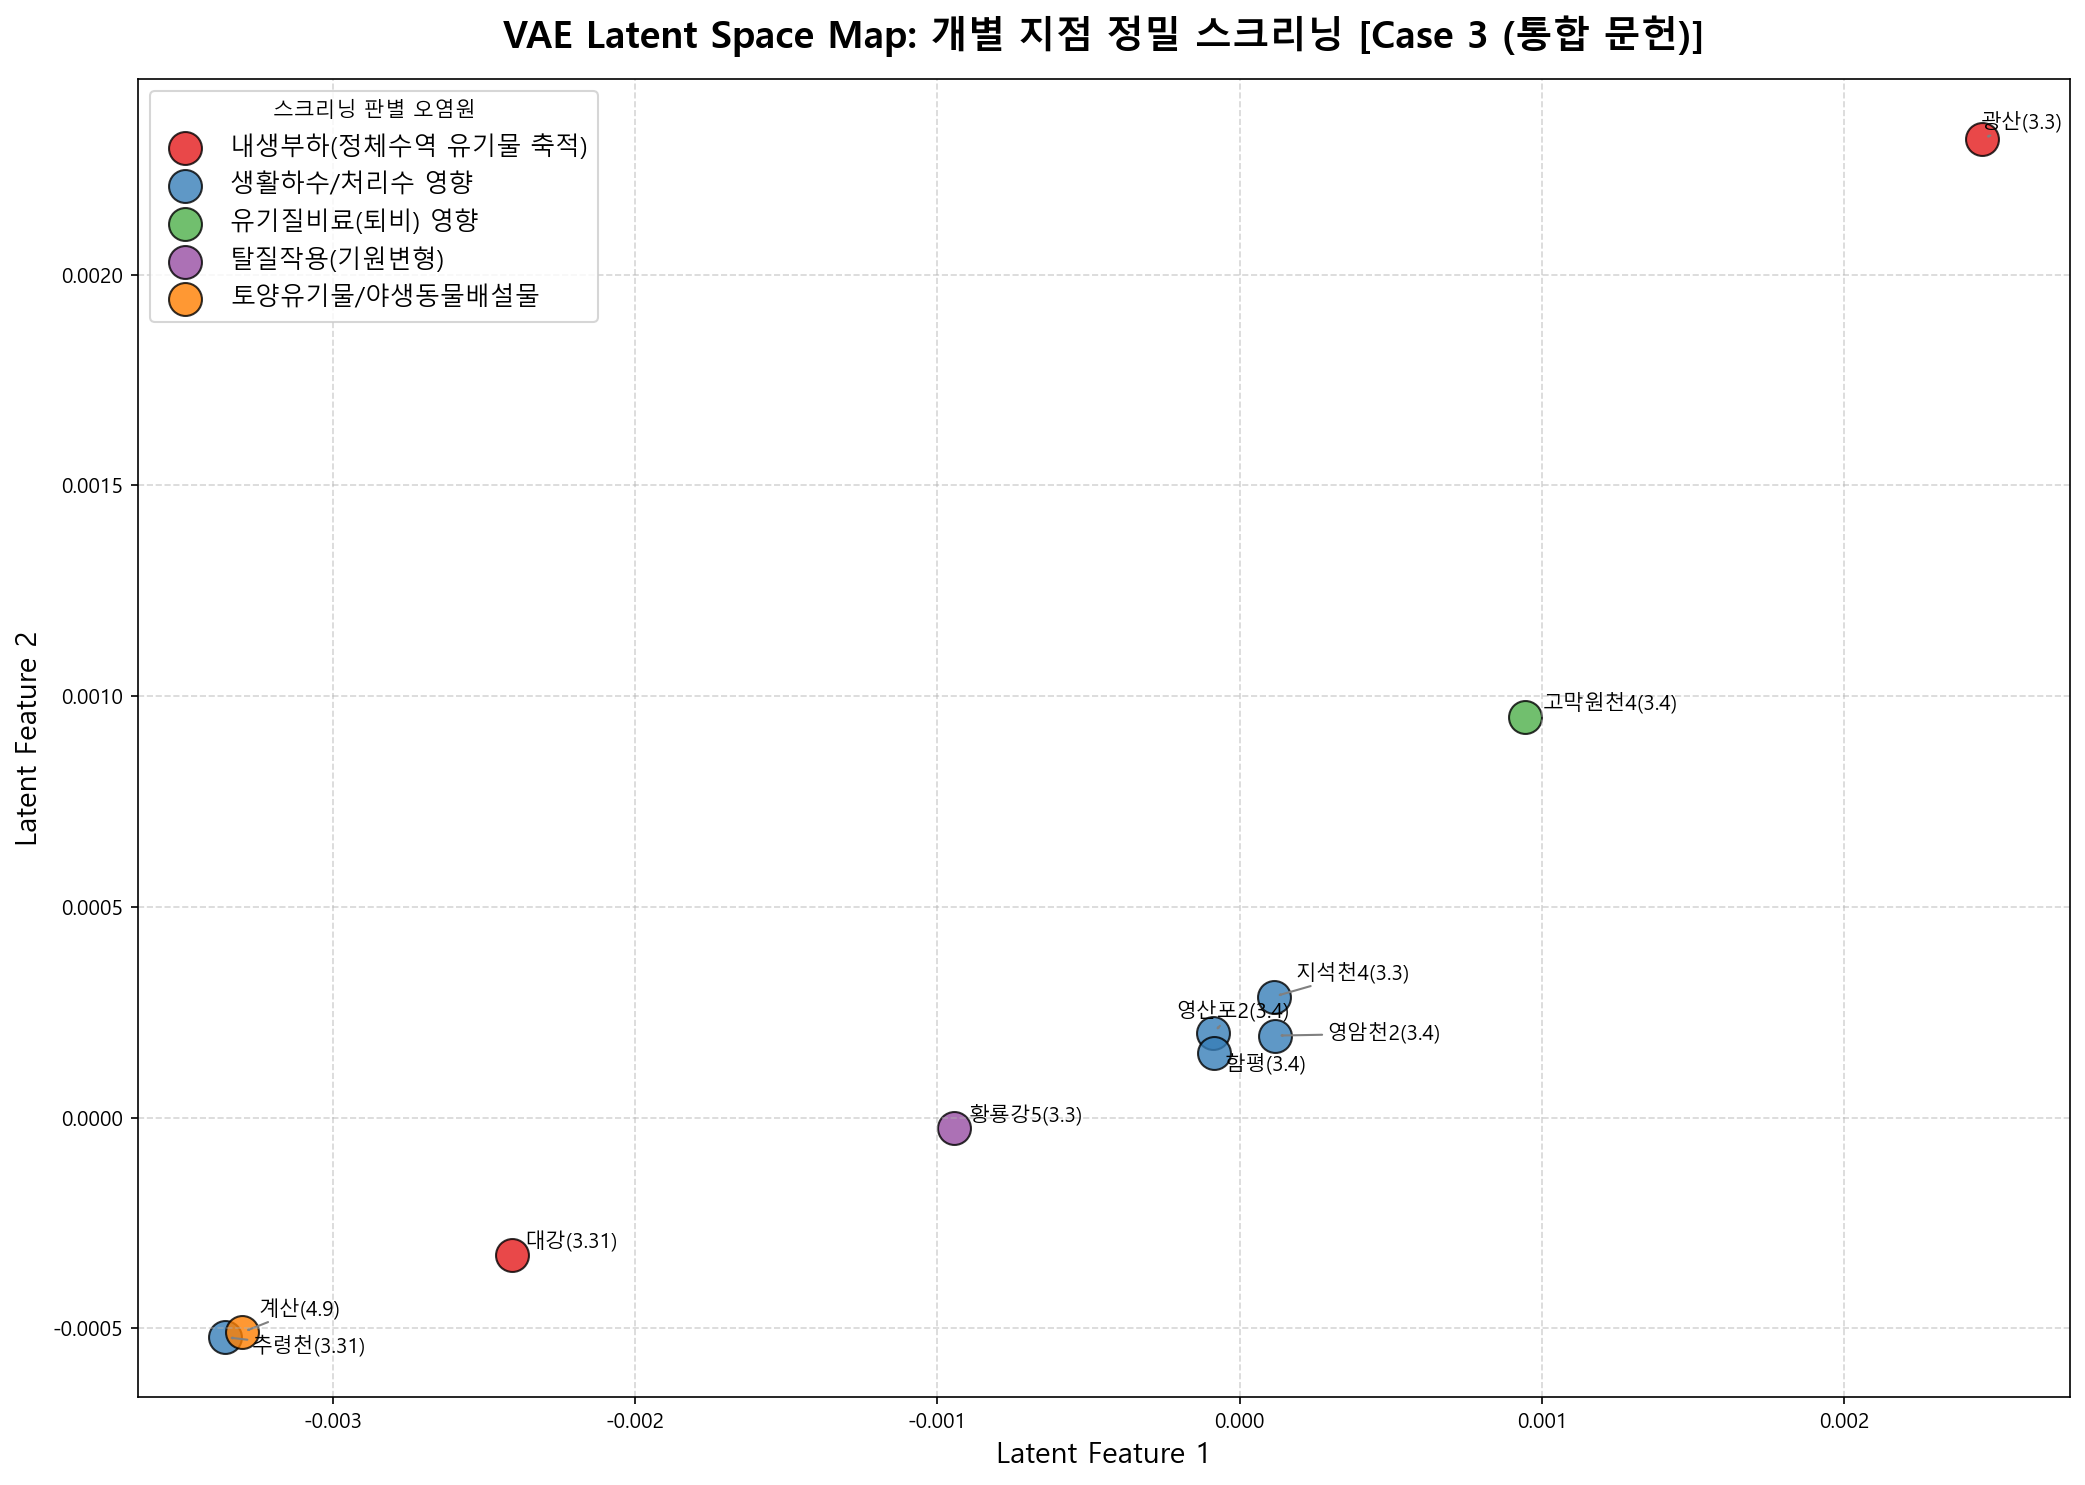

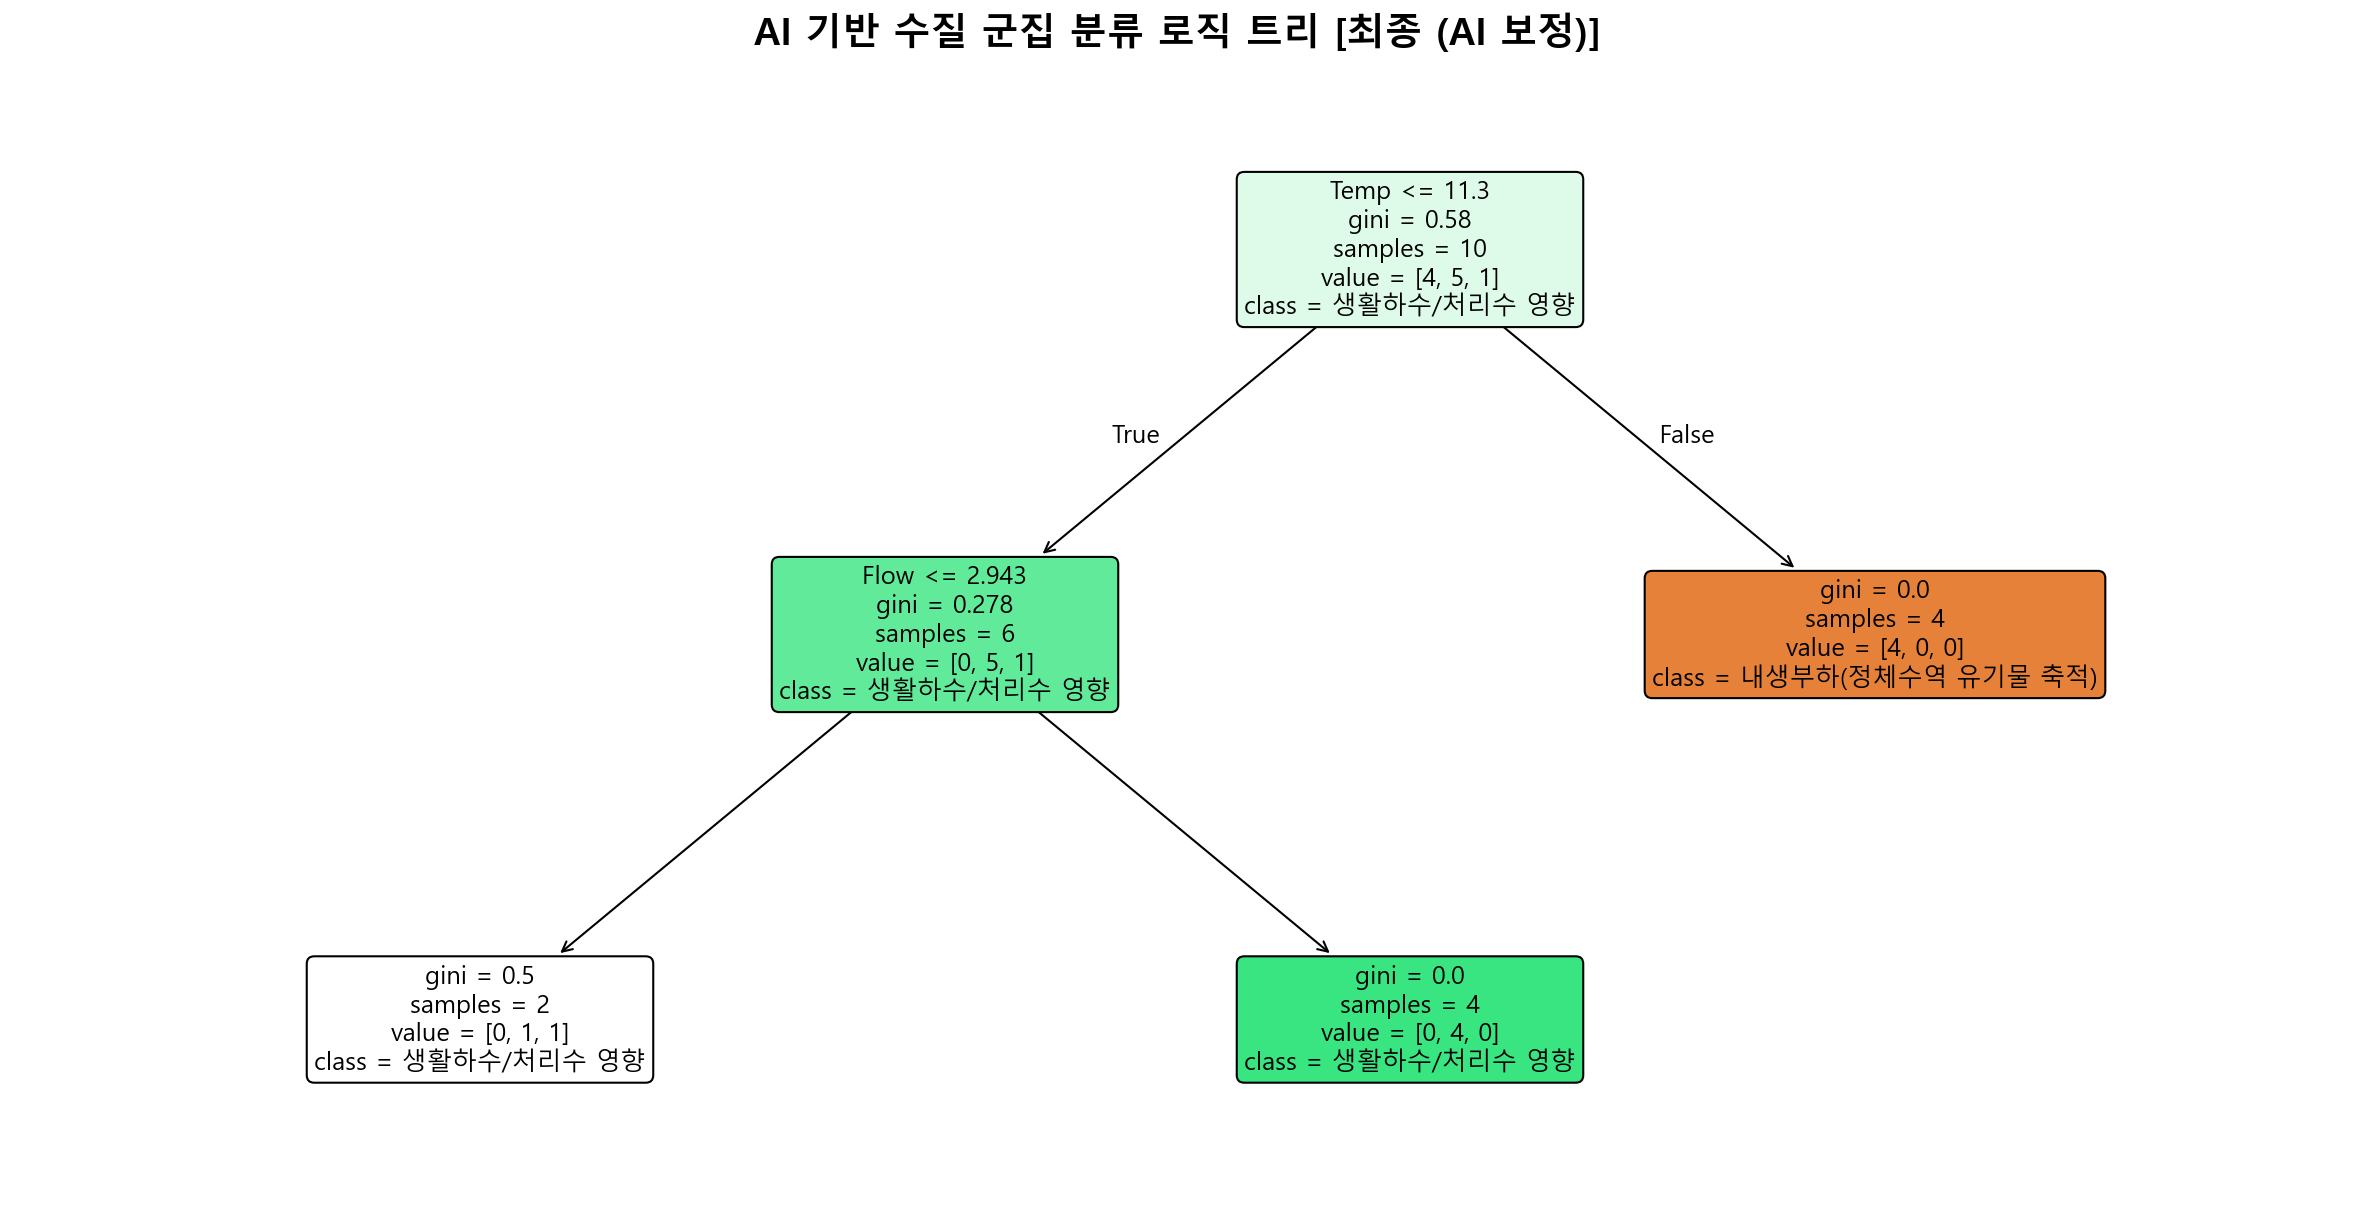

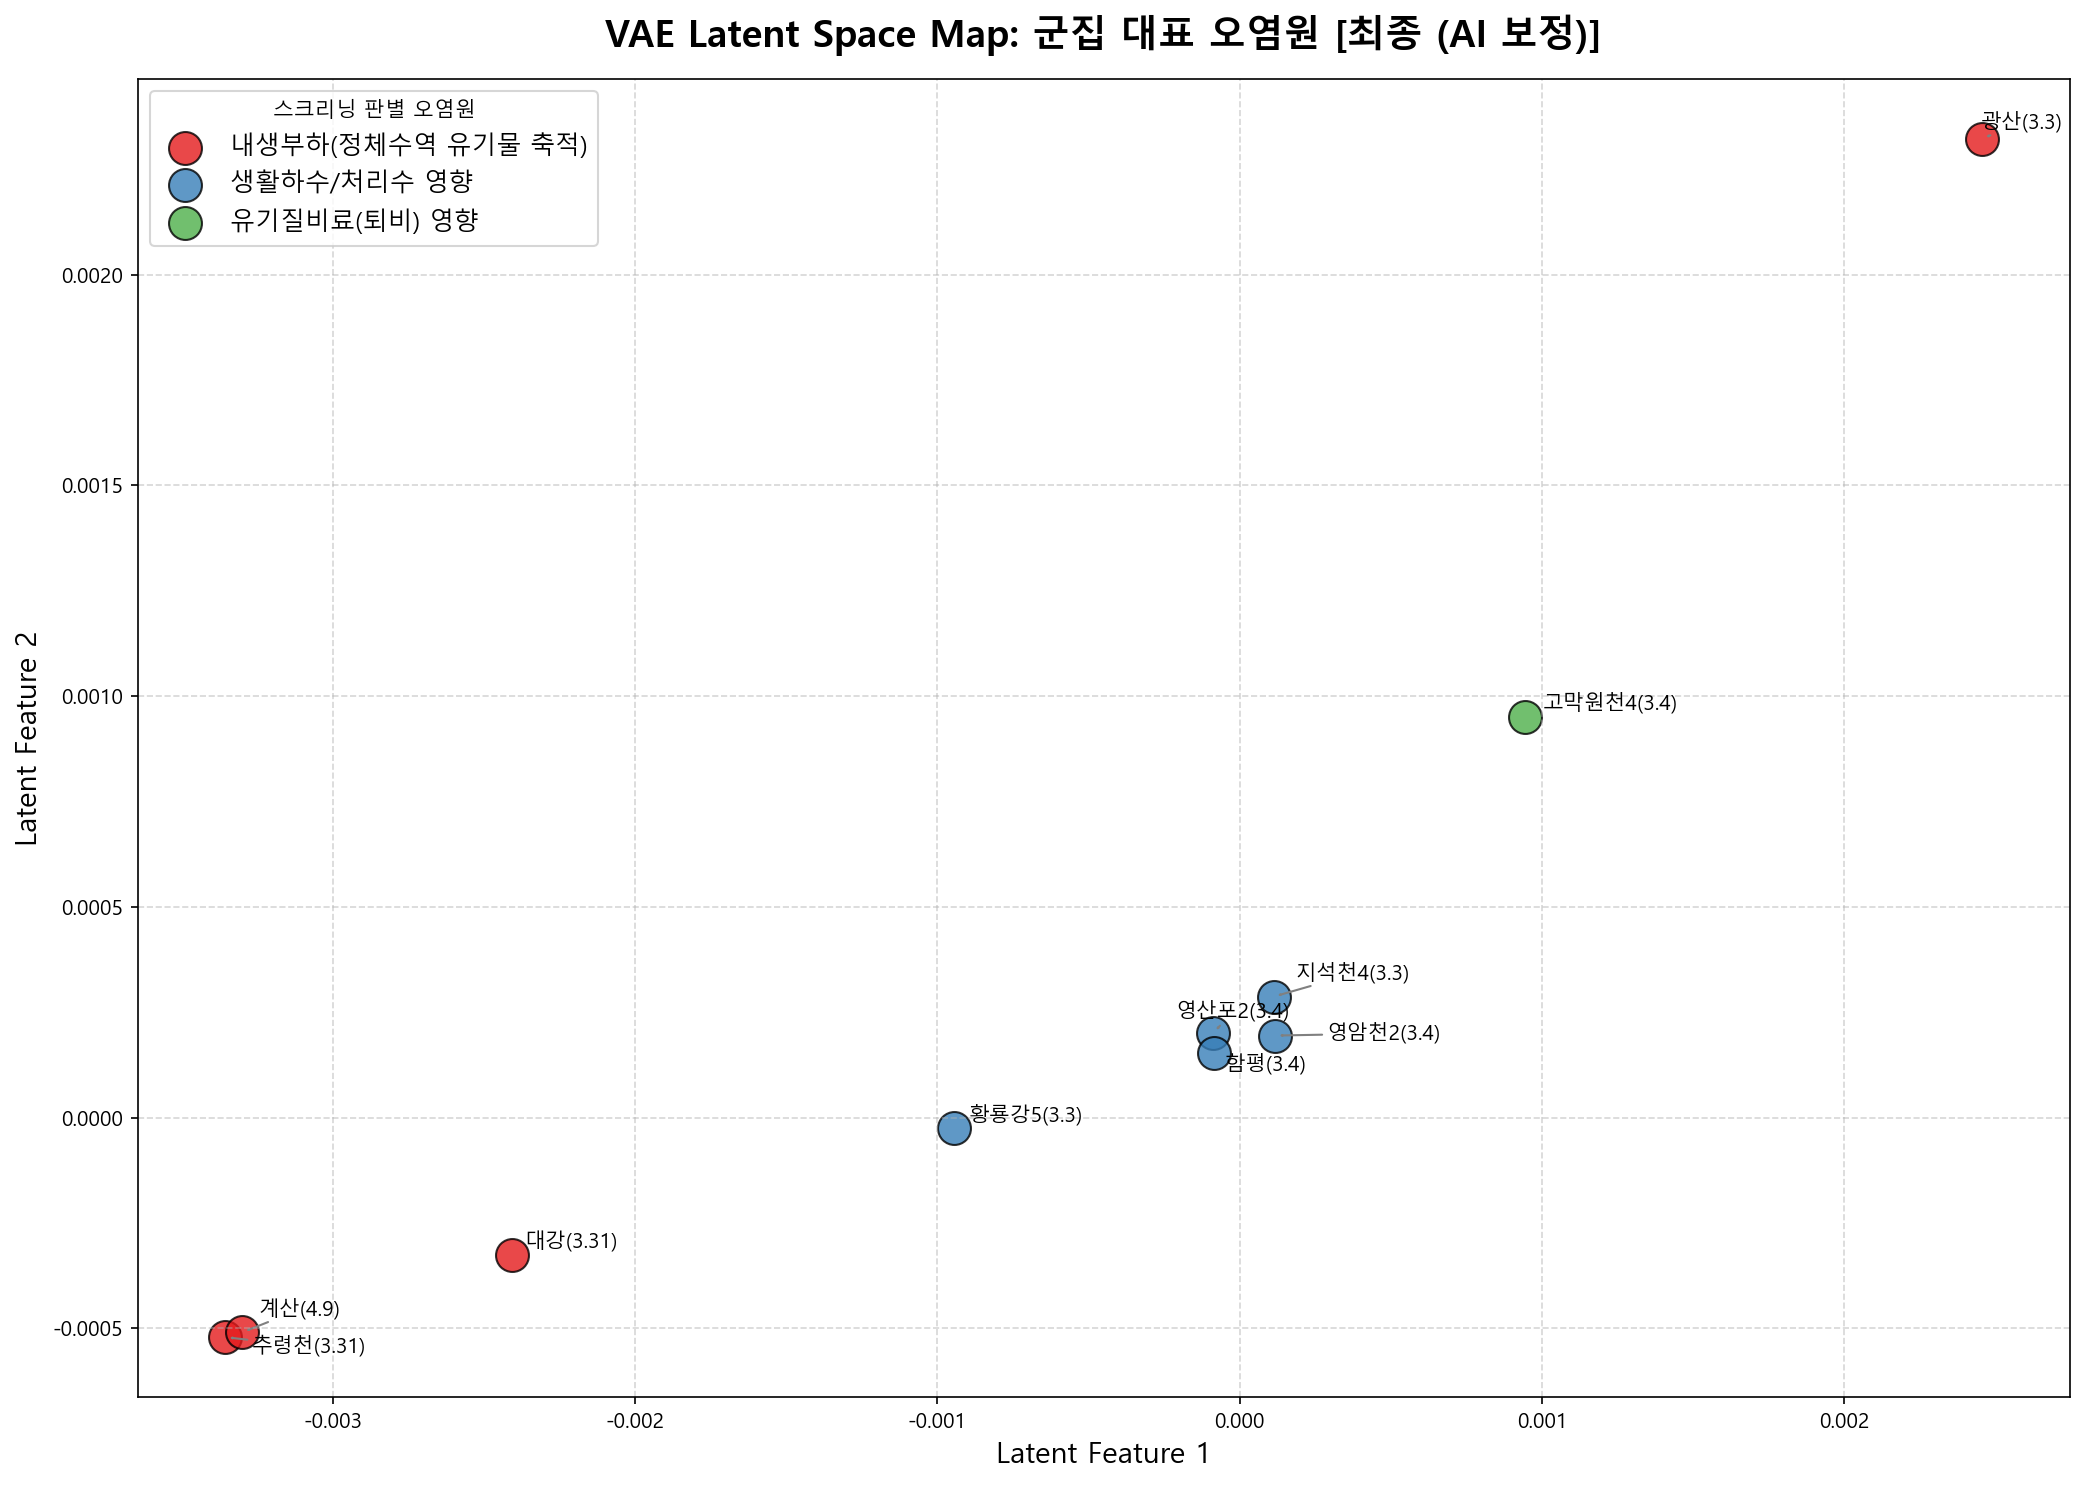

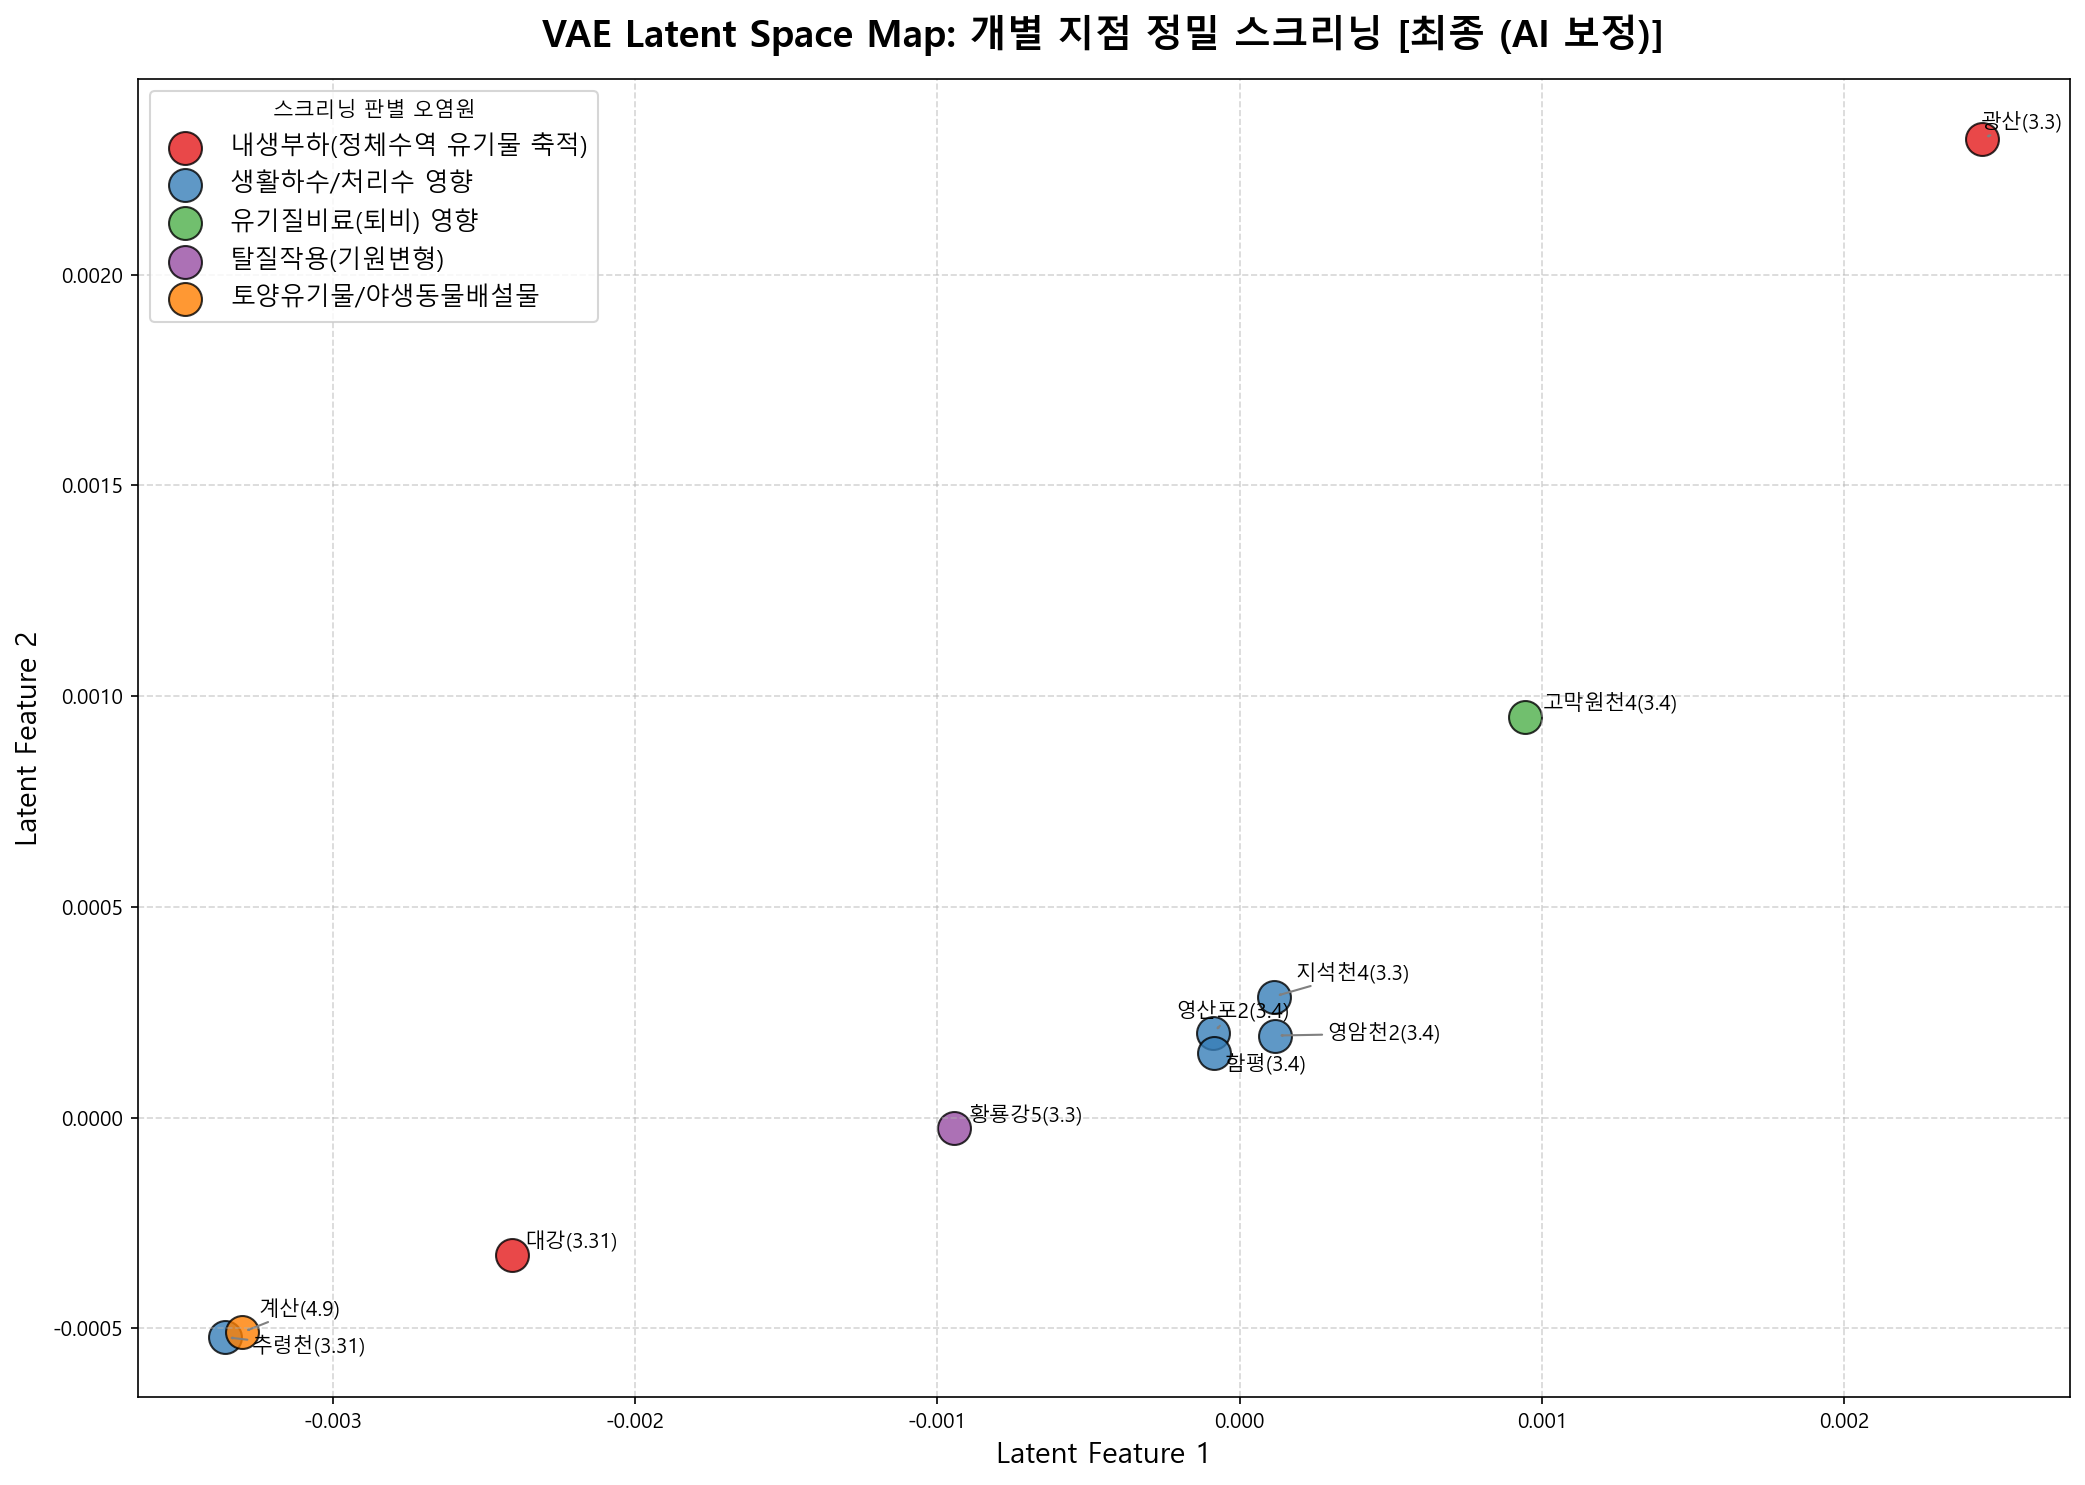

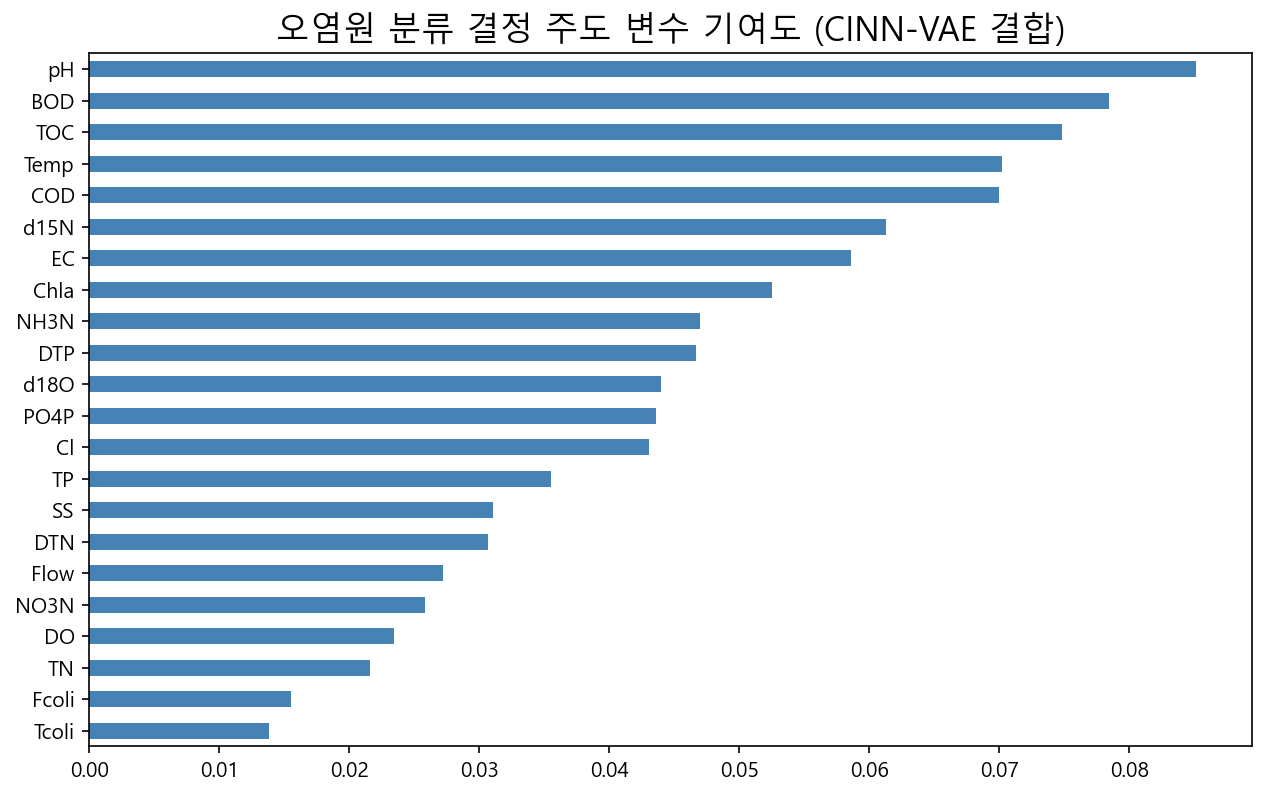

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


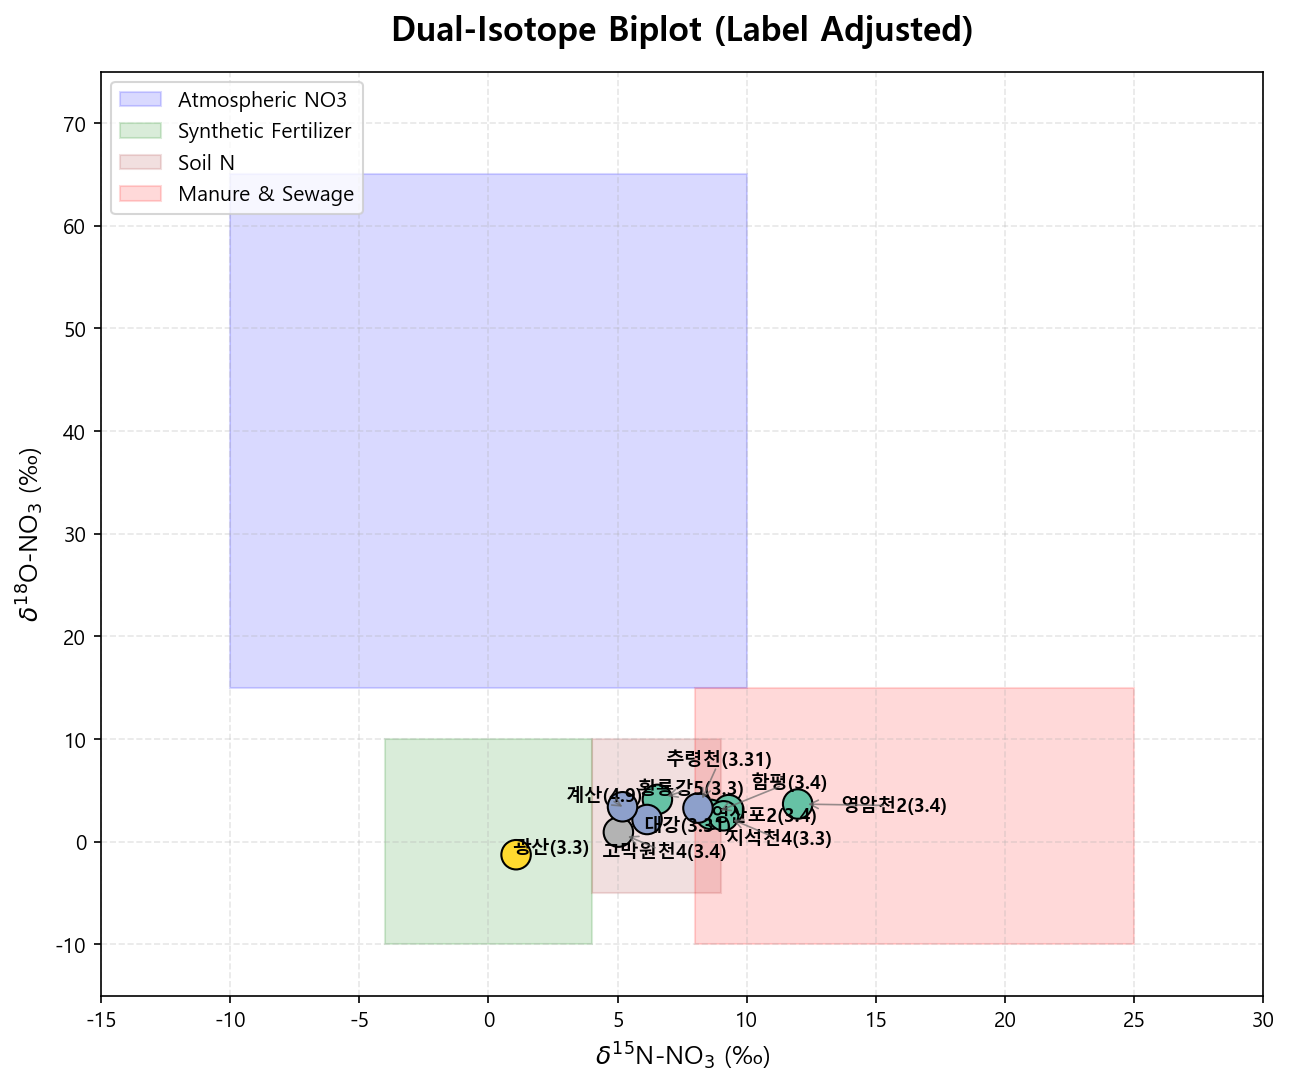

In [9]:
# ------------------------------------------------------------------------------
# 5. 시각화 및 PNG 파일 자동 저장 (XAI)
# 방법론: XAI (Explainable AI) - Decision Tree & Feature Importance (Random Forest)
# 설명: 신경망과 앙상블 군집화는 과정이 투명하지 않은 '블랙박스(Black-box)' 모델입니다. 
#       분석 결과를 연구자와 실무자가 직관적으로 이해할 수 있도록, 의사결정 나무를 통해 
#       어떤 수질 항목의 임계값(Threshold)이 오염원 분류에 결정적이었는지 시각화합니다.
# 참고문헌:
# - Breiman, L. (2001). "Random Forests." Machine Learning, 45(1), 5-32. (변수 중요도 산출의 근거)
# - Lundberg, S. M., & Lee, S. I. (2017). "A unified approach to interpreting model predictions." Advances in neural information processing systems, 30. (XAI를 통한 모델 해석력 확보)
# ------------------------------------------------------------------------------
current_time = datetime.datetime.now().strftime("%y%m%d_%H%M")
print("[*] 4단계: XAI 기반 시각화 및 결과 도출 중...")

# 공통 시각화 함수 정의
def plot_latent_space(target_col, title_suffix, filename):
    plt.figure(figsize=(14, 10))
    unique_vals = df[target_col].dropna().unique()
    colors = sns.color_palette('Set1', len(unique_vals))
    
    for i, val in enumerate(unique_vals):
        mask = df[target_col] == val
        plt.scatter(latent_data[mask, 0], latent_data[mask, 1], 
                    label=val, s=250, color=colors[i], edgecolors='k', alpha=0.8)

    texts = [plt.text(latent_data[i, 0], latent_data[i, 1], df['spot'].iloc[i], fontsize=10) for i in range(len(df))]
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1))

    plt.title(f"VAE Latent Space Map: {title_suffix}", fontsize=18, fontweight='bold', pad=15)
    plt.xlabel("Latent Feature 1", fontsize=14)
    plt.ylabel("Latent Feature 2", fontsize=14)
    plt.legend(title="스크리닝 판별 오염원", loc='best', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{filename}_{current_time}.png"), dpi=300, bbox_inches='tight')
    plt.show()

# 4가지 Case별 반복 처리를 위한 리스트
cases = [
    {'c_col': 'Source_Name1', 'i_col': 'Case1_Source', 'title': 'Case 1 (국내 문헌)', 'fname': 'Case1'},
    {'c_col': 'Source_Name2', 'i_col': 'Case2_Source', 'title': 'Case 2 (국외 문헌)', 'fname': 'Case2'},
    {'c_col': 'Source_Name3', 'i_col': 'Case3_Source', 'title': 'Case 3 (통합 문헌)', 'fname': 'Case3'},
    {'c_col': 'Source_Name',  'i_col': 'Individual_Source', 'title': '최종 (AI 보정)', 'fname': 'Final'}
]

# (1) Decision Tree & (2) Latent Space Map: Case별 반복 시각화
# (1) Decision Tree: 군집별 오염원 결정 논리를 트리 구조로 시각화
# (2) 잠재 공간 지문 지도 (Latent Space Map)
# Autoencoder로 축소한 2차원 또는 3차원 공간(여기서는 앞의 2개 차원 활용)에 투영하여, 
# 오염원 간의 공간적 거리와 분리도를 직관적으로 확인합니다.
# 원본 데이터프레임에서 개별 룰베이스 판별 결과를 가져옵니다.
for case in cases:
    c_name = case['title']
    fname = case['fname']
    c_col = case['c_col']
    i_col = case['i_col']

    # Decision Tree 생성 및 저장
    dt_model = DecisionTreeClassifier(max_depth=8, min_samples_leaf=2, random_state=SEED)
    # 결측/판정보류 데이터 방어를 위해 mask 적용
    valid_mask = df[c_col] != "결측-판정보류"
    if valid_mask.sum() > 0:
        dt_model.fit(imputed_data[valid_mask], df.loc[valid_mask, c_col]) 
        
        plt.figure(figsize=(20, 10))
        plot_tree(dt_model, feature_names=features_df.columns, class_names=[str(c) for c in dt_model.classes_],
                  filled=True, rounded=True, fontsize=12)
        plt.title(f"AI 기반 수질 군집 분류 로직 트리 [{c_name}]", fontsize=18, fontweight='bold')
        plt.savefig(os.path.join(out_dir, f"01_Decision_Tree_{fname}_{current_time}.png"), dpi=300, bbox_inches='tight')
        plt.show()
    
    # Latent Space Map 생성 및 저장
    plot_latent_space(c_col, f'군집 대표 오염원 [{c_name}]', f'02_Latent_Space_Cluster_{fname}')
    plot_latent_space(i_col, f'개별 지점 정밀 스크리닝 [{c_name}]', f'03_Latent_Space_Individual_{fname}')


# (3) Random Forest 변수 중요도 (군집 구조 기반이므로 1번만 구동)
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=SEED).fit(imputed_data, df['Cluster'])
importances = pd.Series(rf.feature_importances_, index=features_df.columns).sort_values()

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue')
plt.title("오염원 분류 결정 주도 변수 기여도 (CINN-VAE 결합)", fontsize=16)
plt.savefig(os.path.join(out_dir, f"04_Feature_Importance_{current_time}.png"), dpi=300, bbox_inches='tight')
plt.show()

# (4) Dual-Isotope biplot (동위원소 산출값이므로 1번만 구동)
fig, ax = plt.subplots(figsize=(10, 8))
ax.add_patch(plt.Rectangle((-10, 15), 20, 50, fill=True, alpha=0.15, color='blue', label='Atmospheric NO3'))
ax.add_patch(plt.Rectangle((-4, -10), 8, 20, fill=True, alpha=0.15, color='green', label='Synthetic Fertilizer'))
ax.add_patch(plt.Rectangle((4, -5), 5, 15, fill=True, alpha=0.15, color='brown', label='Soil N'))
ax.add_patch(plt.Rectangle((8, -10), 17, 25, fill=True, alpha=0.15, color='red', label='Manure & Sewage'))

scatter = ax.scatter(df['d15N'], df['d18O'], c=df['Cluster'], cmap='Set2', s=200, edgecolors='k', zorder=3)
texts = [ax.text(df['d15N'].iloc[i], df['d18O'].iloc[i], txt, fontsize=9, fontweight='semibold') for i, txt in enumerate(df['spot'])]

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='dimgray', lw=0.8, alpha=0.7, shrinkA=5, shrinkB=5), lim=50)

ax.set_xlabel(r'$\delta^{15}$N-NO$_3$ (‰)', fontsize=12)
ax.set_ylabel(r'$\delta^{18}$O-NO$_3$ (‰)', fontsize=12)
ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=False)
ax.grid(alpha=0.3, linestyle='--')
ax.set_title("Dual-Isotope Biplot (Label Adjusted)", fontsize=16, fontweight='bold', pad=15)
ax.set_xlim(-15, 30); ax.set_ylim(-15, 75)

fig.savefig(os.path.join(out_dir, f"05_Dual-Isotope_biplot_{current_time}.png"), dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# ------------------------------------------------------------------------------
# 6. 최종 분석 결과 출력 및 CSV 내보내기
# ------------------------------------------------------------------------------
print("\n=========================================================")
print(" [오염원 자동 스크리닝 최종 레포트 - 고도화 버전]")
print("=========================================================")
# [수정됨] 최종 CSV 출력물에 Source_Name1, 2, 3 및 개별 판별 결과 모두 포함
report_cols = ['spot', 'Source_Name', 'Source_Name1', 'Source_Name2', 'Source_Name3', 
               'Individual_Source', 'Case1_Source', 'Case2_Source', 'Case3_Source', 
               'd15N', 'd18O', 'TN', 'NH3N', 'NO3N', 'TP', 'TOC', 'EC', 'Chla', 'Cl']
               
final_report = df[report_cols].sort_values('Source_Name')

print(final_report.to_string(index=False))

csv_path = os.path.join(out_dir, f"00_Screening_Result_{current_time}.csv")
final_report.to_csv(csv_path, index=False, encoding='euc-kr')

print(f"\n[*] 시스템 프로세스 완료. 모든 산출물(CSV 및 PNG)이 '{out_dir}' 폴더에 정상 저장되었습니다.")


 [오염원 자동 스크리닝 최종 레포트 - 고도화 버전]
      spot       Source_Name      Source_Name1    Source_Name2      Source_Name3 Individual_Source      Case1_Source    Case2_Source      Case3_Source  d15N  d18O    TN  NH3N  NO3N    TP  TOC   EC  Chla      Cl
   광산(3.3) 내생부하(정체수역 유기물 축적) 내생부하(정체수역 유기물 축적) 복합오염(농경지 비점 우세) 내생부하(정체수역 유기물 축적) 내생부하(정체수역 유기물 축적) 내생부하(정체수역 유기물 축적) 복합오염(농경지 비점 우세) 내생부하(정체수역 유기물 축적)  1.07 -1.27 9.069 7.048 1.160 0.403 11.9  412  40.0  66.000
  대강(3.31) 내생부하(정체수역 유기물 축적) 내생부하(정체수역 유기물 축적) 복합오염(농경지 비점 우세) 내생부하(정체수역 유기물 축적) 내생부하(정체수역 유기물 축적) 내생부하(정체수역 유기물 축적) 복합오염(농경지 비점 우세) 내생부하(정체수역 유기물 축적)  6.14  2.16 1.889   NaN   NaN 0.137  7.6  210   NaN  23.702
 추령천(3.31) 내생부하(정체수역 유기물 축적) 내생부하(정체수역 유기물 축적) 복합오염(농경지 비점 우세) 내생부하(정체수역 유기물 축적)       생활하수/처리수 영향       생활하수/처리수 영향      탈질작용(기원변형)       생활하수/처리수 영향  8.11  3.27 3.309   NaN   NaN 0.050  3.6  157  17.3  16.853
   계산(4.9) 내생부하(정체수역 유기물 축적) 내생부하(정체수역 유기물 축적) 복합오염(농경지 비점 우세) 내생부하(정체수역 유기물 축적)     토양유기물/야생동물배설물     토양유기물/야생동물배설물   토양유기물